# Rare Object Detection — Embedding Evaluation & Active Learning

This notebook evaluates the quality of learned embeddings across training runs that vary several hyperparameters:
- **Label fraction `f`**: fraction of the training set that carries morphological labels (0 = fully unsupervised, 1 = fully labelled)
- **Supervision weight `sw`**: relative weight of the supervised contrastive loss term
- **`vicregvar`**, **`cov`**, **`gamma`**: VICReg loss coefficients (variance, covariance, and EMA-target gamma)

Retrieval quality is measured with **nDCG@10** per morphological class. The second half of the notebook runs **Protege** Gaussian-Process active learning on the resulting embeddings to efficiently surface rare/interesting radio galaxies.

All dependencies are installed and imported in the first code cell.

In [37]:
import re
import subprocess
import sys
import torch

# Install dependencies only if missing
def _install(*packages):    
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

try:
    import astronomaly
except ModuleNotFoundError:
    _install("git+https://github.com/MichelleLochner/astronomaly.git")

try:
    import pyarrow
except ModuleNotFoundError:
    _install("pyarrow", "fastparquet", "numpy<2")

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    _install("ipywidgets")
    import ipywidgets as widgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.path import Path as MPath
from pathlib import Path
from collections import defaultdict
from scipy.spatial.distance import cdist
import json
import hashlib

import astronomaly
from astronomaly.anomaly_detection import protege, human_loop_learning
from astronomaly.feature_extraction import shape_features as _sf
from astronomaly.base.base_dataset import Dataset as _AstroDataset

import umap as umap_lib
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest as _IsoForest
from sklearn.model_selection import train_test_split

from IPython.display import display, clear_output

print("astronomaly version:", astronomaly.__version__)
print("numpy version:", np.__version__)
print("pyarrow version:", pyarrow.__version__)

%matplotlib inline

astronomaly version: 2.0
numpy version: 1.26.4
pyarrow version: 14.0.2


## Configuration

Set top-level paths, glob patterns, and evaluation parameters used throughout the notebook. Adjust `OUTPUTS_ROOT`, `RUN_GLOB`, and the data paths to match your local setup.

In [38]:
# ── Config ───────────────────────────────────────────────────────────────────
OUTPUTS_ROOT   = Path("/users/mbredber/p3_SUPLAT/outputs")
RUN_GLOB       = "enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_*_f*_sw*_*"
EVAL_SPLIT     = "test"    # split used for nDCG evaluation
N_CLASSES      = 20        # number of label dimensions
NDCG_K         = 10        # k in nDCG@k

CSV_PATH        = "/users/mbredber/p3_SUPLAT/data/metadata/lotss_classifications_horton_et_al_2025_filtered.csv"
CUTOUT_DIR      = "/users/mbredber/p3_SUPLAT/data/raw/lotss_cutouts"
LABELS_NPY_PATH = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/labels_filtered.npy"
IMAGES_PATH     = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/images_filtered.npy"

# ── Protege run selection ─────────────────────────────────────────────────────
F_LABEL            = 1    # label fraction of the run to analyse
SUPERVISION_WEIGHT = 0.1    # supervision weight of the run to analyse
RUN_NAME_FILTER    = "20260620_2158"   # optional substring to disambiguate (e.g. "extaug", "ed996"); leave "" to pick latest

_run_glob_specific = RUN_GLOB.replace("f*_sw*", f"f{F_LABEL}_sw{SUPERVISION_WEIGHT}")
_matching = sorted(OUTPUTS_ROOT.glob(_run_glob_specific))
if RUN_NAME_FILTER:
    _matching = [r for r in _matching if RUN_NAME_FILTER in r.name]
assert len(_matching) >= 1, (
    f"No runs found matching f={F_LABEL} sw={SUPERVISION_WEIGHT} filter={RUN_NAME_FILTER!r}"
)
if len(_matching) > 1:
    print(f"Warning: {len(_matching)} runs match — using the latest:")
    for r in _matching:
        print(f"  {r.name}")
_run_dir = _matching[-1]   # latest by sorted name (date suffix)
RUN_DIR = str(_run_dir / "data")
print(f"RUN_DIR: {RUN_DIR}")

# ── Protege active-learning hyperparameters ───────────────────────────────────
USE_ENCODINGS = True  # If True, load encodings instead of projections for the GP pipeline
APPLY_PCA = True      # Whether to apply PCA before Protege; set to False to use original features

# Tag encoding latent-space type + PCA choice — used in file/figure names
_latent_tag = ("enc" if USE_ENCODINGS else "proj") + ("_pca" if APPLY_PCA else "")
INITIAL_STEPS  = 200   # number of initial random steps before the first Protege iteration; set to 0 to start with Protege immediately
STEPS_PER_ITER = 100   # number of steps to run between each Protege iteration; set to 0 to run all steps in one go
N_LABELS_TOTAL = 5317 # total number of labels to acquire (including initial random steps)
EPSILON        = 2    # Higher ε means more exploration, lower ε means more exploitation. Paper default is 2. Set to 0 to disable exploration and run pure exploitation (greedy acquisition of top-uncertainty samples).

RUN_DIR: /users/mbredber/p3_SUPLAT/outputs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar5_cov0.05_gamma0.5_f1_sw0.1_20260620_2158/data


## Retrieval Metric: nDCG@10

`nDCGk_avg` computes the mean nDCG@10 score for a given morphological class by treating every member of that class as a query in turn, ranking the remaining embeddings by cosine similarity, and scoring the ranked list against ground-truth labels. A score of 1.0 means all top-10 nearest neighbours belong to the correct class; 0.0 means none do.

In [55]:
def get_relevance(proj_in, lab_in, ref_class, mode="uniform"):
    relevance = np.zeros((proj_in.shape[0],))
    relevance[lab_in[:,ref_class]==True] = 1
    return relevance

def DCG(relevance_descending, k=10):
    num = 2**relevance_descending[:k] - 1
    den = np.log2(1+np.arange(1,k+1))
    return (num/den).sum()

def nDCG(relevance, sorting_cossim, k=10):
    IDCGk = DCG(np.sort(relevance)[::-1], k=k)
    DCGk = DCG(relevance[sorting_cossim], k=k)
    return DCGk/IDCGk

def nDCGk_avg(proj_in, lab_in, ref_class, k=20):
    mask_class = (lab_in[:,ref_class]==True)
    res = []
    for idx_ref in range(mask_class.sum()):
        reference_proj = proj_in[(lab_in[:,ref_class]==True)][idx_ref]
        mask_ref = (np.arange(proj_in.shape[0])==np.argwhere((lab_in[:,ref_class]==True))[idx_ref])
        proj_search = proj_in[~mask_ref]
        cos_d  = cdist(reference_proj[None,:], proj_search,   metric='cosine')
        sorting_cossim = np.argsort(cos_d.squeeze())
        relevance = get_relevance(proj_search, lab_in[~mask_ref], ref_class)
        nDCG_samp = nDCG(relevance, sorting_cossim, k=k)
        res.append(nDCG_samp)
    return (np.asarray(res).mean())

def nDCGk_avg_fast(proj_norm, lab_in, ref_class, k=20):
    """Vectorized nDCG@k. proj_norm must be L2-normalised (call once per run).
    Computes all query similarities in a single matrix multiply instead of
    one cdist call per class member."""
    mask      = lab_in[:, ref_class].astype(bool)
    class_idx = np.where(mask)[0]
    n_class   = len(class_idx)
    if n_class == 0:
        return np.nan

    # (n_class, N) cosine similarity via matmul; exclude self
    sim = proj_norm[class_idx] @ proj_norm.T          # (n_class, N)
    sim[np.arange(n_class), class_idx] = -np.inf

    # Relevance in ranked order for each query
    order      = np.argsort(-sim, axis=1)             # (n_class, N)
    rel_ranked = mask[order][:, :k].astype(float)     # (n_class, k)

    # DCG per query
    discount = 1.0 / np.log2(np.arange(2, k + 2))    # rank 1..k
    dcg      = (rel_ranked * discount).sum(axis=1)    # (n_class,)

    # IDCG is the same for every query: min(k, n_class-1) hits at top ranks
    n_rel = min(k, n_class - 1)
    idcg  = discount[:n_rel].sum() if n_rel > 0 else 0.0

    if idcg == 0:
        return 0.0
    return float((dcg / idcg).mean())

## Multi-Run Comparison

Loads test embeddings from every run directory matching `RUN_GLOB` (a string or list of glob patterns), computes per-class nDCG@10 for each, and collects the results into `run_results` for plotting.

In [56]:
_globs = [RUN_GLOB] if isinstance(RUN_GLOB, str) else RUN_GLOB
run_dirs = sorted({rd for g in _globs for rd in OUTPUTS_ROOT.glob(g)})

def _ndcg_data_seed(rd):
    ckpt = torch.load(rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
    return int(ckpt["config"]["data_seed"])

run_results = []
for rd in run_dirs:
    m = re.search(r'_f([\d.]+)_sw([\d.]+)_', rd.name)
    if not m:
        continue
    f_val  = float(m.group(1))
    sw_val = float(m.group(2))

    byol_dir  = rd / "data" / "byol"
    proj_path = byol_dir / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        # fallback for old runs
        proj_path = rd / "data" / f"{EVAL_SPLIT}_projections.npy"
    if not proj_path.exists():
        print(f"  skipping {rd.name}  (missing {EVAL_SPLIT} projections)")
        continue

    # labels are saved in the shared data_splits dir
    try:
        _ds = _ndcg_data_seed(rd)
    except Exception:
        _ds = 42
    labels_path = OUTPUTS_ROOT / "data_splits" / str(_ds) / f"{EVAL_SPLIT}_labels.npy"
    if not labels_path.exists():
        print(f"  skipping {rd.name}  (missing labels at {labels_path})")
        continue

    proj   = np.load(proj_path)
    labels = np.load(labels_path)
    # L2-normalise once; nDCGk_avg_fast uses a single matmul per class
    norms     = np.linalg.norm(proj, axis=1, keepdims=True)
    proj_norm = proj / np.maximum(norms, 1e-10)
    ndcg = [nDCGk_avg_fast(proj_norm, labels, c, k=NDCG_K) for c in range(N_CLASSES)]
    run_results.append(dict(name=rd.name, f=f_val, sw=sw_val, ndcg=ndcg))
    print(f"  loaded {rd.name}  (f={f_val}, sw={sw_val})")

print(f"\nLoaded {len(run_results)} runs.")


  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.1_20260619_1428  (f=1.0, sw=0.1)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.5_20260619_1517  (f=1.0, sw=0.5)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw1.0_20260619_1605  (f=1.0, sw=1.0)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar1_cov0.1_gamma0.5_f1_sw0.1_20260620_2022  (f=1.0, sw=0.1)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar25_cov0.1_gamma1.0_cwscore1.0_f1_sw0.1_20260619_1056  (f=1.0, sw=0.1)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar25_cov0.1_gamma1.0_cwscore1.0_f1_sw0.5_20260619_1145  (f=1.0, sw=0.5)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar25_cov0.1_gamma1.0_cwscore1.0_f1_sw1.0_20260619_1233  (f=1.0, sw=1.0)
  loaded enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar25_cov0.1_g

### nDCG@10 Results Plot

Each point is one (run, class) pair. **Colour** encodes `sw` on a log-scaled viridis gradient (dark = low, bright = high). **Filled fraction of the circle** encodes `f`: an empty circle means no labels were used; a fully filled circle means all labels were used.

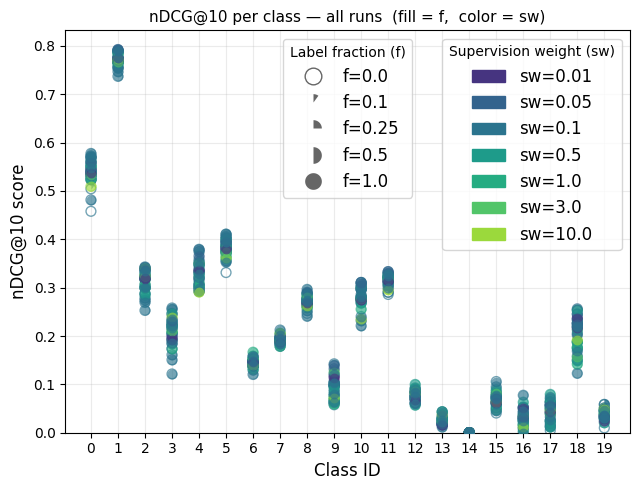

In [57]:
def pie_marker(fraction):
    """Wedge Path covering `fraction` of the unit circle, clockwise from 12 o'clock."""
    if fraction >= 1.0:
        n = 100
        t = np.linspace(0, 2 * np.pi, n, endpoint=False)
        verts = np.column_stack([np.cos(t), np.sin(t)])
        codes = [MPath.MOVETO] + [MPath.LINETO] * (n - 1) + [MPath.CLOSEPOLY]
        return MPath(np.vstack([verts, verts[:1]]), codes)
    n = 50
    t = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi * fraction, n)
    verts = [(0.0, 0.0)] + list(zip(np.cos(t), np.sin(t))) + [(0.0, 0.0)]
    codes = [MPath.MOVETO] + [MPath.LINETO] * n + [MPath.CLOSEPOLY]
    return MPath(verts, codes)


f_vals  = sorted(set(r['f']  for r in run_results))
sw_vals = sorted(set(r['sw'] for r in run_results))

if not run_results:
    print("No run results found — skipping nDCG plot.")
else:
    cmap = plt.cm.viridis
    _sw_arr  = np.array(sw_vals, dtype=float)
    _sw_log  = np.log10(_sw_arr)
    _sw_norm = (_sw_log - _sw_log.min()) / (_sw_log.max() - _sw_log.min() + 1e-9)
    sw_color = {sw: cmap(0.15 + 0.70 * v) for sw, v in zip(sw_vals, _sw_norm)}

    fig, ax = plt.subplots(figsize=(6.5, 5))
    x = np.arange(N_CLASSES)
    S, ALPHA = 50, 0.65

    for r in run_results:
        color = sw_color[r['sw']]
        ax.scatter(x, r['ndcg'], facecolors='none', edgecolors=[color] * N_CLASSES,
                   marker='o', s=S, linewidths=1.0, zorder=2, alpha=ALPHA)
        if r['f'] > 0:
            ax.scatter(x, r['ndcg'], color=color, marker=pie_marker(r['f']),
                       s=S, linewidths=0, zorder=3, alpha=ALPHA)

    ax.set_xlabel("Class ID", fontsize=12)
    ax.set_ylabel("nDCG@10 score", fontsize=12)
    ax.set_ylim([0, None])
    ax.set_xticks(x)
    ax.tick_params(labelsize=10)
    ax.grid(True, alpha=0.25)

    LFS, LMS = 12, 12  # legend fontsize, markersize
    grey = (0.4, 0.4, 0.4)

    f_handles = []
    for f in f_vals:
        if f == 0:
            h = mlines.Line2D([], [], linestyle='None', marker='o', markersize=LMS,
                              markerfacecolor='none', markeredgecolor=grey,
                              markeredgewidth=1.0, label=f'f={f}')
        else:
            h = mlines.Line2D([], [], linestyle='None', marker=pie_marker(f), markersize=LMS,
                              markerfacecolor=grey, markeredgecolor='none', label=f'f={f}')
        f_handles.append(h)

    sw_handles = [
        mpatches.Patch(color=sw_color[sw], label=f'sw={sw}')
        for sw in sw_vals
    ]

    # Stack both legends at upper right
    leg_sw = ax.legend(handles=sw_handles, title='Supervision weight (sw)',
                       loc='upper right', bbox_to_anchor=(1.0, 1.0),
                       framealpha=0.8, fontsize=LFS)
    ax.add_artist(leg_sw)
    ax.legend(handles=f_handles, title='Label fraction (f)',
              loc='upper center', framealpha=0.8, fontsize=LFS)

    ax.set_title("nDCG@10 per class — all runs  (fill = f,  color = sw)", fontsize=11)
    plt.tight_layout()
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_fig_dir / "ndcg_overview.png", dpi=150, bbox_inches="tight")
    plt.show()

## Class Index Mapping

Based on the LoTSS classifications (Horton et al. 2025), the 20-dimensional
label vector corresponds to the following classes:

| Index | Column          | Classification       | Type        | N sources |
|-------|-----------------|----------------------|-------------|-----------|
| 0     | `fri`           | FRI                  | Initial     | 2992      |
| 1     | `frii`          | FRII                 | Initial     | 6231      |
| 2     | `hybrid`        | Hybrids              | Initial     | 966       |
| 3     | `spiral`        | Spirals              | Initial     | 234       |
| 4     | `relaxed`       | Relaxed doubles      | Initial     | 440       |
| 5     | `cshaped`       | C-curvature          | Morphology  | 2379      |
| 6     | `sshaped`       | S-curvature          | Morphology  | 1082      |
| 7     | `misaligned`    | Misalignment         | Morphology  | 1287      |
| 8     | `wings`         | Wings                | Morphology  | 1564      |
| 9     | `xshaped`       | X-shaped             | Morphology  | 179       |
| 10    | `straight`      | Straight jets        | Morphology  | 358       |
| 11    | `multihotspots` | Multiple hotspots    | Morphology  | 2040      |
| 12    | `continuous`    | Continuous jets      | Morphology  | 337       |
| 13    | `banding`       | Banding              | Morphology  | 133       |
| 14    | `onesided`      | One-sided            | Morphology  | 23        |
| 15    | `restarted`     | Restarted            | Morphology  | 193       |
| 16    | `cluster`       | Cluster              | Environment | 72        |
| 17    | `merger`        | Merger               | Environment | 63        |
| 18    | `diffuse`       | Diffuse emission     | Environment | 111       |
| 19    | `unknown`       | Unknown              | Environment | 126       |

### Protege interest scoring

Each source is assigned the score of its most interesting label (multi-label sources take the highest applicable score).
Counts are from the full 7596-row dataset (`labels_filtered.npy`), before any train/val/test split.
Positives (score ≥ 3): **1303** (17.2%).

| Score | Label(s) | Count | % |
|-------|----------|-------|---|
| 4 | `xshaped`, `unknown`, `cluster`, `merger` | 285 | 3.8% |
| 3 | `diffuse`, `sshaped`, `spiral` | 1018 | 13.4% |
| 2 | `restarted`, `onesided`, `banding`, `cshaped`, `wings`, `misaligned`, `multihotspots`, `relaxed` | 3480 | 45.8% |
| 1 | `fri`, `frii`, `hybrid`, `straight`, `continuous`, (none of the above) | 2813 | 37.0% |
| **Total** | | **7596** | **100%** |

In [58]:
LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]  # must match the column order used when labels_filtered.npy was saved

SCORE_4 = ["xshaped", "unknown", "cluster", "merger"]
SCORE_3 = ["diffuse", "sshaped", "spiral"]
SCORE_2 = ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "multihotspots", "relaxed"]
SCORE_1 = ["fri", "frii", "hybrid", "straight", "continuous"]

POSITIVE_THRESHOLD = 3     # sources with human_label >= this are "interesting"

### Average nDCG@10 by Interest Score

Groups the 20 morphological classes into four interest tiers (1 = common, 4 = rarest) and computes the mean nDCG@10 within each tier across all `(f, sw)` combinations, giving a compact view of retrieval quality per rarity level.

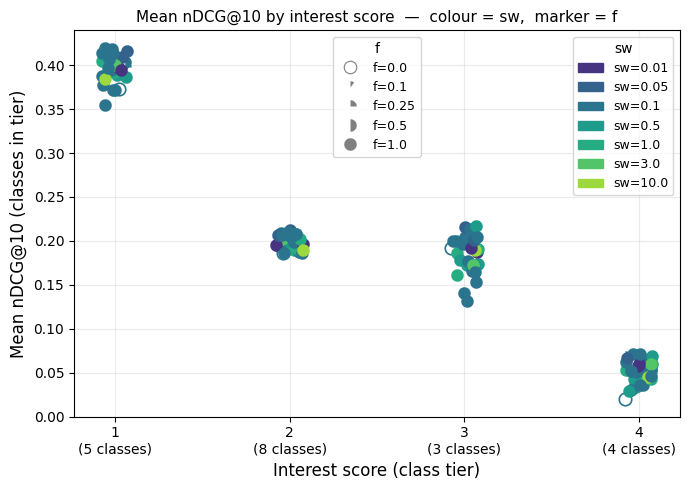

In [59]:
# ── Average nDCG@10 by interest score and (f, sw) combination ────────────────

# Map class index → interest score using the same tier definitions as Protege config
_LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]
_SCORE_MAP = {col: 1 for col in _LABEL_COLS}
for col in ["xshaped", "unknown", "cluster", "merger"]:
    _SCORE_MAP[col] = 4
for col in ["diffuse", "sshaped", "spiral"]:
    _SCORE_MAP[col] = 3
for col in ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "multihotspots", "relaxed"]:
    _SCORE_MAP[col] = 2
_class_interest = np.array([_SCORE_MAP[c] for c in _LABEL_COLS])

interest_scores = sorted(set(_class_interest))
is_indices = {s: np.where(_class_interest == s)[0] for s in interest_scores}

fig, ax = plt.subplots(figsize=(7, 5))

runs_by_f = {}
for r in run_results:
    runs_by_f.setdefault(r['f'], []).append(r)

rng_jitter = np.random.default_rng(0)

for f_val in sorted(runs_by_f):
    marker = pie_marker(f_val) if f_val > 0 else 'o'
    for r in runs_by_f[f_val]:
        c = sw_color[r['sw']]
        mkw = dict(markerfacecolor='none', markeredgecolor=c, markeredgewidth=1.2) if f_val == 0 \
              else dict(markerfacecolor=c, markeredgecolor='none')
        for score in interest_scores:
            idxs = is_indices[score]
            vals = [r['ndcg'][i] for i in idxs if not np.isnan(r['ndcg'][i])]
            if not vals:
                continue
            y = np.mean(vals)
            jitter = rng_jitter.uniform(-0.08, 0.08)
            ax.plot(score + jitter, y, marker=marker, markersize=9,
                    linestyle='none', zorder=3, **mkw)

# Legends
f_handles = [
    mlines.Line2D([], [], color='grey', linewidth=0,
                  marker=pie_marker(f) if f > 0 else 'o',
                  markersize=9,
                  markerfacecolor='grey' if f > 0 else 'none',
                  markeredgecolor='grey',
                  markeredgewidth=0.8 if f == 0 else 0,
                  label=f'f={f}')
    for f in sorted(runs_by_f)
]
sw_handles = [mpatches.Patch(color=sw_color[sw], label=f'sw={sw}') for sw in sw_vals]

leg_sw = ax.legend(handles=sw_handles, title='sw', loc='upper right', fontsize=9, framealpha=0.8)
ax.add_artist(leg_sw)
ax.legend(handles=f_handles, title='f', loc='upper center', fontsize=9, framealpha=0.8)

# Annotate x-ticks with class count per tier
xtick_labels = [f'{s}\n({len(is_indices[s])} classes)' for s in interest_scores]
ax.set_xticks(interest_scores)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_xlabel('Interest score (class tier)', fontsize=12)
ax.set_ylabel('Mean nDCG@10 (classes in tier)', fontsize=12)
ax.set_title('Mean nDCG@10 by interest score  —  colour = sw,  marker = f', fontsize=11)
ax.grid(True, alpha=0.25)
ax.set_ylim(bottom=0)
plt.tight_layout()
_fig_dir = OUTPUTS_ROOT / "figures" / "protege"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "ndcg_by_interest_score.png", dpi=150, bbox_inches="tight")
plt.show()

## Protege Active Learning Integration

Uses the [astronomaly](https://github.com/MichelleLochner/astronomaly) library to run a Gaussian-Process active learner on the learned embeddings. The GP iteratively selects the most informative unlabelled sources via an acquisition function, simulates a human labelling step using ground-truth morphology scores, and updates the model — surfacing rare/interesting sources far more efficiently than random inspection.

The GP is run in **transductive** mode: all sources (train + test) contribute to the kernel covariance, but only train sources can be queried. Final scores are predicted for all sources; test-set scores are used to evaluate recall.

Results from each single-run execution are persisted to `{RUN_DIR}/protege/` (i.e. `data/protege/` within the run directory) as `notebook_protege_{latent}_eps{EPSILON}_q{N_LABELS_TOTAL}.parquet`. The recall-curve cell automatically overlays all saved runs with different `EPSILON` values, so epsilon sweeps can be compared visually without re-running everything.

### Load Embeddings and Morphology Labels

Load the split's projection embeddings and positional row indices, join to the source catalogue CSV to recover `Source_Name` and per-class morphology flags, and convert the multi-label flags into a 1–5 human-interest score (5 = rarest/most exotic morphology).

In [60]:
RUN_DIR_ = Path(RUN_DIR)

# ── Derive shared splits directory ────────────────────────────────────────────
_run_dir_root = RUN_DIR_.parent   # RUN_DIR ends in /data, so parent = run dir
_ckpt_for_seed = torch.load(_run_dir_root / "byol_model_best.pt",
                             map_location="cpu", weights_only=False)
_data_seed_  = int(_ckpt_for_seed["config"]["data_seed"])
_splits_dir_ = _run_dir_root.parent / "data_splits" / str(_data_seed_)

# Derive f-string matching the filename suffix used by train_byol.py
_f_label_ = _ckpt_for_seed["config"].get("f_label", F_LABEL)
_f_str_   = str(_f_label_).rstrip('0').rstrip('.') if '.' in str(_f_label_) else str(int(_f_label_))

def _load_idx_(name):
    """Load idx array: tries f-suffixed version first (new runs), then base name, then data_dir (old runs)."""
    stem, ext = name.rsplit('.', 1)
    p_fsuffix = _splits_dir_ / f"{stem}_f{_f_str_}.{ext}"
    p_base    = _splits_dir_ / name
    if p_fsuffix.exists():
        return np.load(p_fsuffix)
    elif p_base.exists():
        return np.load(p_base)
    else:
        return np.load(RUN_DIR_ / name)

# Feature files are in data/byol/ (new runs) or data/ (old runs)
_byol_dir_ = RUN_DIR_ / "byol" if (RUN_DIR_ / "byol").exists() else RUN_DIR_

# ── Load features + indices (handles f=0, f=1, and mixed 0<f<1) ─────────────
# USE_ENCODINGS selects encodings vs projections; both are saved by train_byol.py.
# For 0<f<1: labelled-only file; combine with unlabelled.
# For f=0: labelled file holds ALL train features (no unlabelled file).
# For f=1: all train sources are labelled — load from labelled files.
_feat_suffix     = "encodings" if USE_ENCODINGS else "projections"
_lab_proj        = np.load(_byol_dir_ / f"labelled_train_{_feat_suffix}.npy")
_lab_idx         = _load_idx_("labelled_train_idx.npy")
_unlab_idx       = _load_idx_("unlabelled_train_idx.npy")
_unlab_proj_path = _byol_dir_ / f"unlabelled_train_{_feat_suffix}.npy"

if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    projections = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    idx_arr     = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0: labelled_train_projections.npy contains all train projections
    projections = _lab_proj
    idx_arr     = _unlab_idx
else:                       # f=1: all sources are labelled
    projections = _lab_proj
    idx_arr     = _lab_idx

print(f"features ({_feat_suffix}): {projections.shape}  idx_arr: {idx_arr.shape}")
print(f"idx_arr max value: {idx_arr.max()}")
print(f"idx_arr min value: {idx_arr.min()}")
print(f"Any idx >= 7596 (npy length): {(idx_arr >= 7596).sum()}")

# Load CSV only for Source_Name — row order matches images_filtered.npy for the first 7596 rows
csv_df       = pd.read_csv(CSV_PATH)
source_names = csv_df.iloc[idx_arr]["Source_Name"].values

features_df = pd.DataFrame(projections, index=source_names)

# ── Load labels from the aligned .npy file (NOT the CSV) ──────────────────
# images_filtered.npy and labels_filtered.npy are row-aligned companions.
# The CSV has 7607 rows vs 7596 in the npy files — they are NOT aligned,
# so csv_df.iloc[idx_arr] gives wrong labels. Use labels_filtered.npy instead.

labels_all   = np.load(LABELS_NPY_PATH)       # shape (7596, 20)
labels_split = labels_all[idx_arr]            # shape (N_split, 20) — aligned with projections

# Build a DataFrame for convenient column access
labels_npy_df = pd.DataFrame(labels_split.astype(bool), columns=LABEL_COLS)

# Build human_label (1–4) from tier scoring
TIERS = [(4, SCORE_4), (3, SCORE_3), (2, SCORE_2)]
human_labels = np.ones(len(labels_npy_df), dtype=int)
for score_val, cols in reversed(TIERS):
    mask = labels_npy_df[cols].any(axis=1).values
    human_labels[mask] = score_val

labels_df = pd.DataFrame({"human_label": human_labels}, index=source_names)

print("human_label distribution:")
print(pd.Series(human_labels).value_counts().sort_index())
binary_label = (human_labels >= 4).astype(int)
print(f"\nPositives (score≥4): {binary_label.sum()}  |  Negatives: {(binary_label==0).sum()}")

# ── Load test projections + labels (needed for UMAP and Protege eval) ────────
_test_idx   = _load_idx_("test_idx.npy")
_test_proj  = np.load(_byol_dir_ / f"test_{_feat_suffix}.npy")

# Guard against drop_last truncation: test_projections may have fewer rows than test_idx
# (happens when the training script uses drop_last=True for the test loader)
_n_test = len(_test_proj)
if _n_test < len(_test_idx):
    print(f"  Warning: test_projections ({_n_test}) < test_idx ({len(_test_idx)}), trimming to match.")
    _test_idx = _test_idx[:_n_test]

_test_names = csv_df.iloc[_test_idx]["Source_Name"].values

_test_labels_raw = labels_all[_test_idx]
_test_labels_df  = pd.DataFrame(_test_labels_raw.astype(bool), columns=LABEL_COLS)
_test_human      = np.ones(len(_test_labels_df), dtype=int)
for _sv, _cols in reversed(TIERS):
    _test_human[_test_labels_df[_cols].any(axis=1).values] = _sv

labels_df = pd.concat([
    labels_df,
    pd.DataFrame({"human_label": _test_human}, index=_test_names),
])

# Combined train + test arrays (used by UMAP and PCA cells)
n_train   = len(projections)
all_proj  = np.concatenate([projections, _test_proj], axis=0)
all_names = np.concatenate([source_names, _test_names])

print(f"\nTest sources: {len(_test_idx)}  |  Total (train+test): {len(all_proj)}")

features (encodings): (5317, 1280)  idx_arr: (5317,)
idx_arr max value: 7595
idx_arr min value: 1
Any idx >= 7596 (npy length): 0
human_label distribution:
1    1959
2    2438
3     725
4     195
Name: count, dtype: int64

Positives (score≥4): 195  |  Negatives: 5122

Test sources: 2279  |  Total (train+test): 7596


### Image Gallery

Shows 5 example images per interest score (1–4) to give a visual intuition for what each tier looks like.

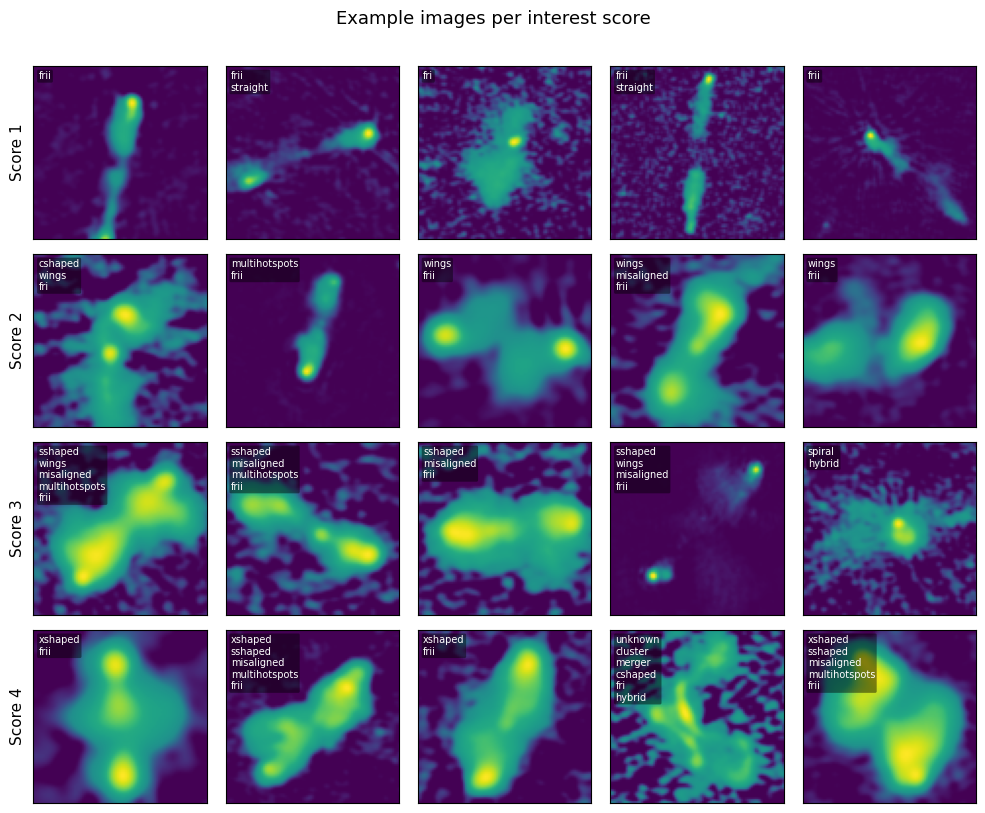

In [61]:
# Show 5 example images for each interest score (1–4)
images_all = np.load(IMAGES_PATH)
images = images_all[idx_arr]  # align with current split

ALL_MORPH_COLS = SCORE_4 + SCORE_3 + SCORE_2 + SCORE_1

N_EXAMPLES = 5
scores = [1, 2, 3, 4]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(scores), N_EXAMPLES, figsize=(N_EXAMPLES * 2, len(scores) * 2))

for row, score in enumerate(scores):
    idxs = np.where(human_labels == score)[0]
    chosen = rng.choice(idxs, size=min(N_EXAMPLES, len(idxs)), replace=False)
    for col in range(N_EXAMPLES):
        ax = axes[row, col]
        if col < len(chosen):
            img = images[chosen[col]]
            if img.ndim == 3:
                img = img[0]  # take first channel if multi-channel
            ax.imshow(img, cmap='viridis', origin='lower')
            # Class labels: all True morphology columns for this source
            row_data = labels_npy_df.iloc[chosen[col]]
            active = [c for c in ALL_MORPH_COLS if row_data.get(c, False)]
            label_str = "\n".join(active) if active else "none"
            ax.text(0.03, 0.97, label_str, transform=ax.transAxes,
                    fontsize=7, color="white", va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.45, lw=0))
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"Score {score}", fontsize=11, labelpad=6)

fig.suptitle("Example images per interest score", fontsize=13, y=1.01)
plt.tight_layout()
_fig_dir = OUTPUTS_ROOT / "figures" / "protege"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "example_images_by_score.png", dpi=150, bbox_inches="tight")
plt.show()

### UMAP Projection

2-D UMAP of all sources (train + test), coloured by interest score. Cached to `umap_all_coords.npy` in the run directory for fast reloading.

Loaded UMAP from cache (7596 sources)


Saved figure to /users/mbredber/p3_SUPLAT/outputs/figures/protege/umap_interest_score.png


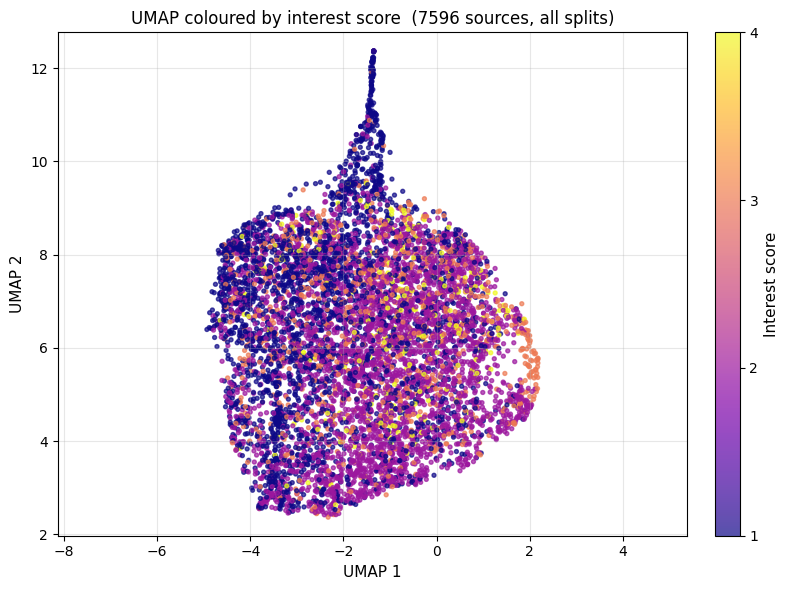

In [62]:
# UMAP is fitted on all sources (train + test) to match the training-script output.
_umap_new = Path(RUN_DIR) / "umap" / "umap_projections_coords.npy"
_umap_old = Path(RUN_DIR) / "umap_all_coords.npy"
_umap_cache = _umap_new if _umap_new.exists() else _umap_old
_all_human_labels = labels_df.loc[all_names, "human_label"].values
if _umap_cache.exists() and np.load(_umap_cache).shape[0] == all_proj.shape[0]:
    _emb2d = np.load(_umap_cache)
    print(f"Loaded UMAP from cache ({len(_emb2d)} sources)")
else:
    print(f"Fitting UMAP on {all_proj.shape[0]} sources...")
    _reducer = umap_lib.UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42)
    _emb2d = _reducer.fit_transform(all_proj)
    _umap_new.parent.mkdir(parents=True, exist_ok=True)
    np.save(_umap_new, _emb2d)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    _emb2d[:, 0], _emb2d[:, 1],
    c=_all_human_labels, cmap='plasma',
    s=8, alpha=0.7, vmin=1, vmax=4,
)
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Interest score', fontsize=11)
cbar.set_ticks([1, 2, 3, 4])
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_aspect('equal', adjustable='datalim')
ax.grid(True, alpha=0.3)
ax.set_title(f'UMAP coloured by interest score  ({len(_emb2d)} sources, all splits)',
             fontsize=12)
plt.tight_layout()

# Save before plt.show(), which otherwise clears the figure from memory.
_fig_out = OUTPUTS_ROOT / "figures" / "protege" / "umap_interest_score.png"
_fig_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(_fig_out, dpi=300, bbox_inches='tight')
print(f"Saved figure to {_fig_out}")

plt.show()

### KNN Nearest-Neighbour Gallery

For each SCORE_4 class, picks one random member as a query and shows its 8 nearest neighbours in embedding space. A yellow border on the centre image marks the query; neighbours are ranked by cosine distance.

/tmp/ipykernel_104261/1845504099.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


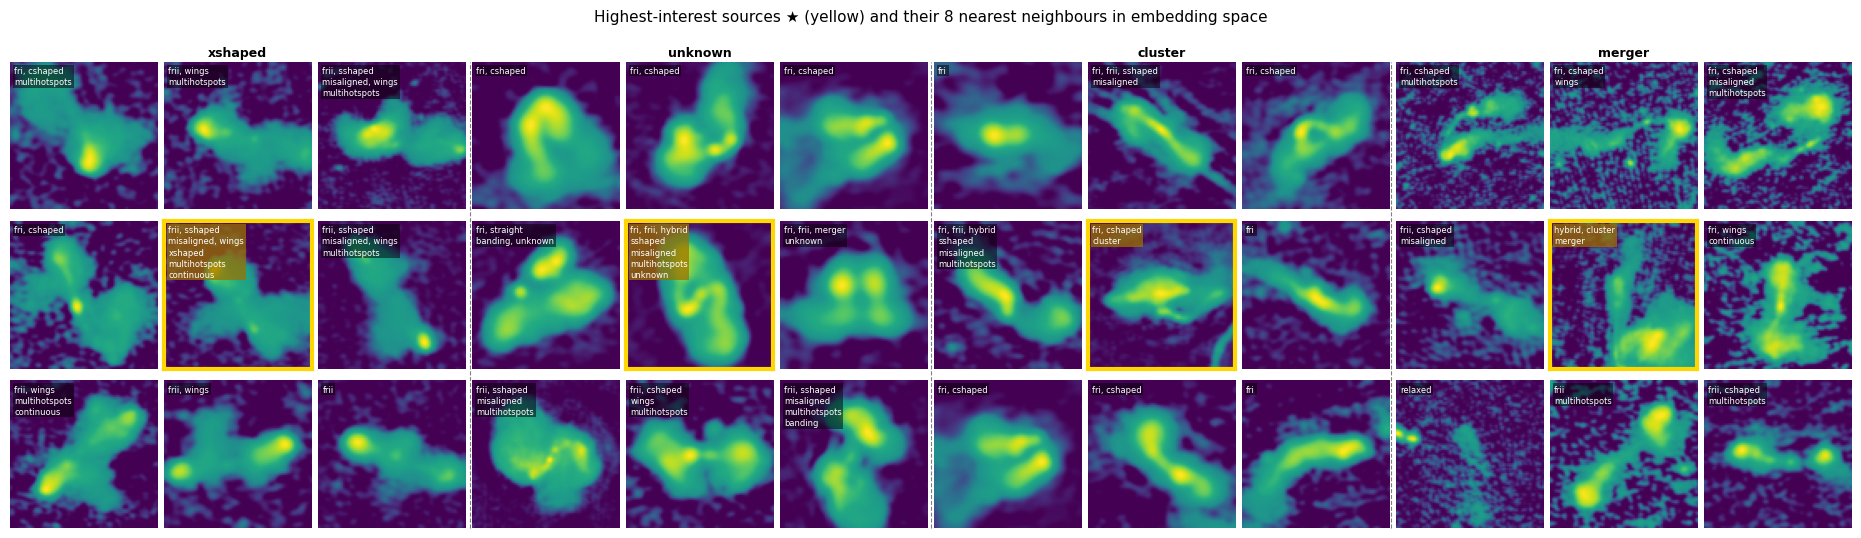

In [63]:
# =============================================================================
# KNN Gallery — highest-interest sources (SCORE_4 classes)
# Centre cell (yellow border) = query image (one random example per class).
# Surrounding 8 cells = nearest neighbours in embedding space.
# =============================================================================
KNN_SEED = 42

def _wrap_label(names, max_chars=18):
    lines, cur = [], ''
    for p in names:
        cand = f'{cur}, {p}' if cur else p
        if len(cand) > max_chars and cur:
            lines.append(cur); cur = p
        else:
            cur = cand
    if cur: lines.append(cur)
    return '\n'.join(lines)

rng_knn = np.random.default_rng(KNN_SEED)

nn_model = NearestNeighbors(n_neighbors=9, metric='euclidean').fit(projections)

# One random query per SCORE_4 class
queries = []
for cls in SCORE_4:
    candidates = np.where(labels_npy_df[cls].values)[0]
    if len(candidates) == 0:
        continue
    idx = rng_knn.choice(candidates)
    queries.append((cls, idx))

N_queries = len(queries)
cell_size  = 1.6
left_mar, right_mar, top_mar, bottom_mar = 0.02, 0.02, 0.10, 0.02

fig, axes = plt.subplots(
    3, 3 * N_queries,
    figsize=(cell_size * 3 * N_queries, cell_size * 3 + 0.5),
    gridspec_kw={'wspace': 0.03, 'hspace': 0.08},
)
fig.subplots_adjust(left=left_mar, right=1 - right_mar,
                    top=1 - top_mar, bottom=bottom_mar)

_, knn_all = nn_model.kneighbors(projections[[idx for _, idx in queries]])

for qi, (cls, q_idx) in enumerate(queries):
    neighbours = [i for i in knn_all[qi] if i != q_idx][:8]
    col_offset = qi * 3

    grid = [neighbours[0], neighbours[1], neighbours[2],
            neighbours[3], None,          neighbours[4],
            neighbours[5], neighbours[6], neighbours[7]]

    q_img = images[q_idx]
    if q_img.ndim == 3: q_img = q_img[0]

    # Title above the centre column
    axes[0, col_offset + 1].set_title(cls, fontsize=9, fontweight='bold', pad=4)

    for flat_pos, real_idx in enumerate(grid):
        row     = flat_pos // 3
        col_pos = col_offset + (flat_pos % 3)
        ax      = axes[row, col_pos]

        if real_idx is None:
            # Centre: query image with yellow border
            ax.imshow(q_img, cmap='viridis', origin='lower')
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
            q_active = [c for c in LABEL_COLS if labels_npy_df.iloc[q_idx][c]]
            ax.text(0.03, 0.97, _wrap_label(q_active),
                    transform=ax.transAxes, fontsize=6, color='white',
                    va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='#9a7200', alpha=0.75, pad=1, linewidth=0))
        else:
            nb_img = images[real_idx]
            if nb_img.ndim == 3: nb_img = nb_img[0]
            ax.imshow(nb_img, cmap='viridis', origin='lower')
            ax.axis('off')
            nb_active = [c for c in LABEL_COLS if labels_npy_df.iloc[real_idx][c]]
            ax.text(0.03, 0.97, _wrap_label(nb_active) if nb_active else '—',
                    transform=ax.transAxes, fontsize=6, color='white',
                    va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

    if qi < N_queries - 1:
        plot_width = 1 - left_mar - right_mar
        x_sep = left_mar + plot_width * (col_offset + 3) / (3 * N_queries)
        fig.add_artist(plt.matplotlib.lines.Line2D(
            [x_sep, x_sep], [bottom_mar, 1 - top_mar],
            transform=fig.transFigure,
            color='grey', linewidth=0.8, linestyle='--', zorder=10,
        ))

fig.suptitle('Highest-interest sources ★ (yellow) and their 8 nearest neighbours in embedding space',
             fontsize=11, y=0.999)
plt.tight_layout()
_fig_dir = OUTPUTS_ROOT / "figures" / "protege"
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / "knn_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

### Gaussian Process Active Learning Loop

Defines `run_GP_active_learning`, which wraps the Protege GP pipeline: it seeds `initial_steps` sources, then iteratively selects the highest-acquisition unlabelled sources, reveals ground-truth labels, and re-fits the GP until `N_labels` sources have been labelled.

The cell also standardises the full projection matrix with `StandardScaler` so the GP kernel operates on unit-variance features.

In [64]:
def run_GP_active_learning(features, labels, input_anomaly_scores, output_dir,
                           steps=10, initial_steps=None, N_labels=100, epsilon=0.5,
                           labelable_index=None):
    anomaly_scores = input_anomaly_scores.copy()
    anomaly_scores['human_label'] = [-1] * len(anomaly_scores)
    pipeline_active_learning = protege.GaussianProcess(
        features, force_rerun=True, output_dir=output_dir, ei_tradeoff=epsilon)

    def _pick_unlabeled(df, n):
        mask = df['human_label'] == -1
        if labelable_index is not None:
            mask = mask & df.index.isin(labelable_index)
        return df[mask].index[:n]

    if initial_steps is not None:
        anomaly_scores.sort_values('score', ascending=False, inplace=True)
        inds = _pick_unlabeled(anomaly_scores, initial_steps)
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    else:
        initial_steps = 0
    for i in range(initial_steps // steps, N_labels // steps):
        anomaly_scores.sort_values('acquisition', ascending=False, inplace=True)
        inds = _pick_unlabeled(anomaly_scores, steps)
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    return anomaly_scores, pipeline_active_learning


### PCA Dimensionality Reduction

Fits a PCA on the combined train+test projections (no prior scaling) and reports how many components explain 95% and 99% of variance. The embeddings are then projected to the 95%-variance component count to produce `features_pca`, which is passed to the GP active learner.

Embedding dim: 1280d  (analysis PCA on first 128 components)
  Dims for 95% variance: >128
  Dims for 99% variance: >128
  Variance captured by 128 components: 0.920


/tmp/ipykernel_104261/2453095847.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


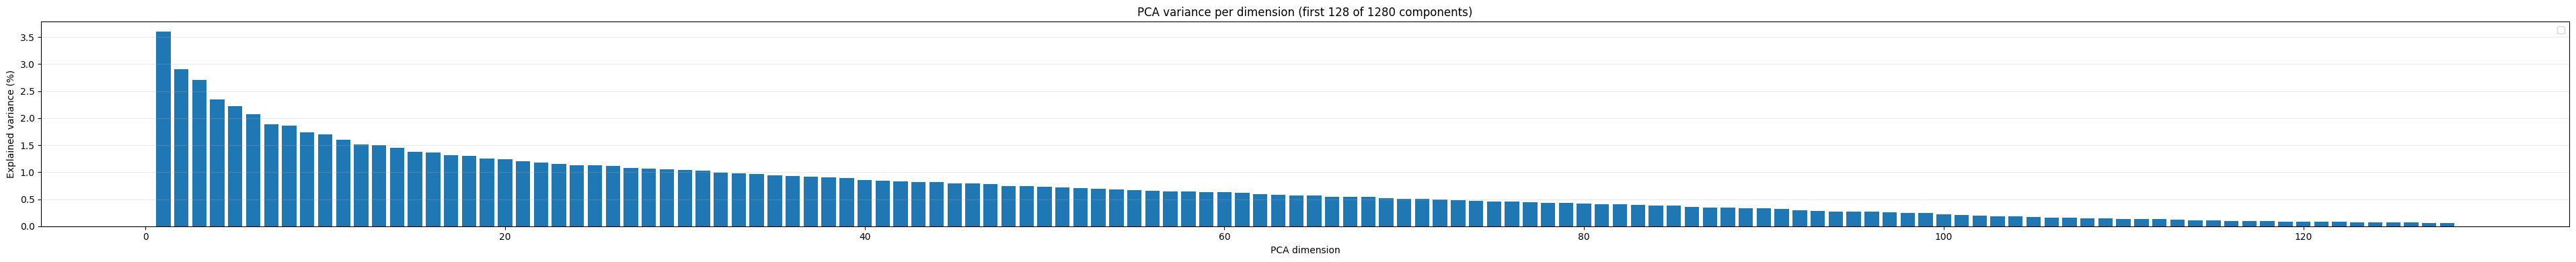


PCA applied: 1280d → 209d (0.950 variance retained)
features_pca: (7596, 209)  (train=5317, test=2279)


In [49]:
# No scaling — PCA will be applied directly to the raw projections if enabled.
all_proj_scaled    = all_proj
projections_scaled = all_proj[:n_train]
test_proj_scaled   = all_proj[n_train:]

# Always fit a partial PCA for variance analysis (fast: only 128 components)
_n_analysis = min(128, all_proj.shape[1])
_pca_analysis = PCA(n_components=_n_analysis, random_state=42)
_pca_analysis.fit(all_proj_scaled)

_cumvar = np.cumsum(_pca_analysis.explained_variance_ratio_)
_n_95   = int(np.searchsorted(_cumvar, 0.95)) + 1 if _cumvar[-1] >= 0.95 else f">{_n_analysis}"
_n_99   = int(np.searchsorted(_cumvar, 0.99)) + 1 if _cumvar[-1] >= 0.99 else f">{_n_analysis}"
print(f"Embedding dim: {all_proj.shape[1]}d  (analysis PCA on first {_n_analysis} components)")
print(f"  Dims for 95% variance: {_n_95}")
print(f"  Dims for 99% variance: {_n_99}")
print(f"  Variance captured by {_n_analysis} components: {_cumvar[-1]:.3f}")

fig, ax = plt.subplots(figsize=(max(6, _n_analysis * 0.3), 4))
ax.bar(np.arange(1, _n_analysis + 1), _pca_analysis.explained_variance_ratio_ * 100, color="tab:blue")
if isinstance(_n_95, int):
    ax.axvline(_n_95, color="tab:orange", linestyle="--", linewidth=1.2, label=f"95% variance ({_n_95}d)")
if isinstance(_n_99, int):
    ax.axvline(_n_99, color="tab:red",    linestyle=":",  linewidth=1.2, label=f"99% variance ({_n_99}d)")
ax.set_xlabel("PCA dimension")
ax.set_ylabel("Explained variance (%)")
ax.set_title(f"PCA variance per dimension (first {_n_analysis} of {all_proj.shape[1]} components)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

_figures_dir = OUTPUTS_ROOT / "figures" / "protege"
_pca_fig_path = _figures_dir / "pca_variance.png"
if not _pca_fig_path.exists():
    _figures_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_pca_fig_path, dpi=150, bbox_inches="tight")
    print(f"  Saved missing pca_variance.png to {_pca_fig_path}")

plt.show()

if APPLY_PCA:
    pca = PCA(n_components=0.95, random_state=42)
    projections_pca  = pca.fit_transform(projections_scaled)
    test_proj_pca    = pca.transform(test_proj_scaled)
    all_proj_pca     = np.concatenate([projections_pca, test_proj_pca], axis=0)
    features_pca     = pd.DataFrame(all_proj_pca, index=all_names)
    print(f"\nPCA applied: {all_proj.shape[1]}d → {projections_pca.shape[1]}d "
          f"({pca.explained_variance_ratio_.sum():.3f} variance retained)")
else:
    features_pca = pd.DataFrame(all_proj_scaled, index=all_names)
    print(f"\nPCA not applied — using full {all_proj.shape[1]}d embeddings.")

print(f"features_pca: {features_pca.shape}  (train={n_train}, test={len(all_proj)-n_train})")
assert len(features_pca) == len(all_proj), "features_pca row count mismatch!"

### Run Gaussian Process Active Learning

Seeds the GP with `INITIAL_STEPS` evenly-spaced train sources using ground-truth interest scores, then calls `run_GP_active_learning` to run the full active-learning loop. Results are saved to `{RUN_DIR}/protege/` as a parquet file.

In [50]:
assert len(features_pca) > n_train, (
    f"features_pca has {len(features_pca)} rows but n_train={n_train}: "
    "no test rows — re-run the PCA cell before this one.")
features_train = features_pca.iloc[:n_train]
features_test  = features_pca.iloc[n_train:]

_nb_protege_dir = Path(RUN_DIR) / "protege"
_nb_protege_dir.mkdir(parents=True, exist_ok=True)

# Seed with human_label values (1–4) for INITIAL_STEPS evenly-spaced sources
# so the GP starts with real signal rather than a degenerate binary 0/1 split.
anomaly_scores = pd.DataFrame({'score': np.zeros(len(features_pca))}, index=features_pca.index)
seed_positions = np.linspace(0, n_train - 1, INITIAL_STEPS, dtype=int)
seed_names = features_train.index[seed_positions]
anomaly_scores.loc[seed_names, 'score'] = labels_df.loc[seed_names, 'human_label'].values.astype(float)
n_positive_seeds = (labels_df.loc[seed_names, 'human_label'] >= POSITIVE_THRESHOLD).sum()
print(f"Seed set: {INITIAL_STEPS} sources, {n_positive_seeds} with score >= {POSITIVE_THRESHOLD} "
      f"({100 * n_positive_seeds / INITIAL_STEPS:.1f}%)")

# Normalise scores with ScoreConverter
score_converter = human_loop_learning.ScoreConverter(force_rerun=True, output_dir=str(_nb_protege_dir))
anomaly_scores = score_converter.run(anomaly_scores)

# ── Diagnostic: score distribution after ScoreConverter ──────────────────
print("\n── anomaly_scores after ScoreConverter ──")
print(anomaly_scores.describe())
print("\nscore value_counts (top 10):")
print(anomaly_scores['score'].value_counts().head(10))
n_unique = anomaly_scores['score'].nunique()
print(f"\nUnique score values: {n_unique}")
if n_unique == 1:
    print("WARNING: all scores are identical — GP has no signal to start from!")
score_min = anomaly_scores['score'].min()
score_max = anomaly_scores['score'].max()
print(f"\nScoreConverter output range: [{score_min:.4f}, {score_max:.4f}]")
if score_min == score_max:
    print("WARNING: ScoreConverter output is constant — GP has no gradient to learn from!")
elif score_max - score_min < 0.1:
    print("WARNING: ScoreConverter output range is very narrow — GP signal may be weak.")
# ─────────────────────────────────────────────────────────────────────────────

# Cap N_LABELS_TOTAL to the number of labelable train sources so the loop
# cannot keep iterating after all sources are exhausted.
_n_labels = min(N_LABELS_TOTAL, n_train)
if _n_labels < N_LABELS_TOTAL:
    print(f"N_LABELS_TOTAL capped: {N_LABELS_TOTAL} → {_n_labels} (= n_train)")

# Run transductive active learning: GP sees all sources (train + test),
# but labeling is restricted to train sources via labelable_index.
active_output, gp_pipeline = run_GP_active_learning(
    features_pca,                          # all sources — transductive GP
    labels_df.loc[features_train.index],   # labels available only for train
    anomaly_scores,
    output_dir=str(_nb_protege_dir),
    steps=STEPS_PER_ITER,
    initial_steps=INITIAL_STEPS,
    N_labels=_n_labels,
    epsilon=EPSILON,
    labelable_index=features_train.index,  # restrict labeling to train sources
)
print("Active learning complete. Train labelled:", (active_output.loc[features_train.index, 'human_label'] > 0).sum())

# Test sources were scored inside the GP run (permanently unlabeled, human_label == -1)
test_output = active_output.loc[features_test.index, ['trained_score']].copy()
test_output['human_label'] = -2   # restore sentinel for downstream cell compat
print(f"Test scored: {len(test_output)}  score>=3: {(labels_df.loc[features_test.index,'human_label']>=3).sum()}")

# ── Persist this run's scores for epsilon comparison ─────────────────────────
_save_name = f"notebook_protege_{_latent_tag}_eps{EPSILON:g}_q{N_LABELS_TOTAL}.parquet"
_save_path = _nb_protege_dir / _save_name

_train_save = active_output.loc[features_train.index, ['trained_score', 'acquisition', 'human_label']].copy()
_test_save  = test_output[['trained_score', 'human_label']].copy()
_test_save['acquisition'] = float('nan')
_combined = pd.concat([_train_save, _test_save])
_combined.to_parquet(_save_path)
print(f"Saved → {_save_path}")

Seed set: 200 sources, 27 with score >= 3 (13.5%)
/users/mbredber/p3_SUPLAT/outputs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar5_cov0.05_gamma0.5_f1_sw0.1_20260620_2158/data/protege/ellipses_gp/astronomaly.log
Now switching to new log file:
/users/mbredber/p3_SUPLAT/outputs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar5_cov0.05_gamma0.5_f1_sw0.1_20260620_2158/data/protege/astronomaly.log
Running ScoreConverter ...
Running anomaly score rescaler...
Done! Time taken: 0.011948347091674805 s

── anomaly_scores after ScoreConverter ──
             score
count  7596.000000
mean      4.942075
std       0.381024
min       0.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       5.000000

score value_counts (top 10):
score
5.00    7396
2.50      95
3.75      78
1.25      24
0.00       3
Name: count, dtype: int64

Unique score values: 5

ScoreConverter output range: [0.0000, 5.0000]
Running GaussianProcess ...
Running GP regression with 200 traini

KeyboardInterrupt: 

### Recall Curve

Ranks queried-train and test sources by the GP's `trained_score` and plots cumulative interesting-source counts (label ≥ `POSITIVE_THRESHOLD`) on two side-by-side subplots (train left, test right). Baselines overlaid for comparison:
- **Orange** — BYOL (this run)
- **Steelblue dashed** — Complexity (featurecount ranking)
- **Green dotted** — Ellipses GP (IsoForest + Protege GP on shape features)
- **Dark grey dashed** — Random baseline

The figure is saved to `{RUN_DIR}/../figures/recall_curves_{latent}_eps{EPSILON}.png`. The cell also scans `{RUN_DIR}/protege/` for previously saved runs at other `EPSILON` values and overlays them on the test subplot for direct epsilon comparison.

In [ ]:
# ── Compute / load baselines (complexity + ellipses) on the test set ─────────
# Ellipses IsoForest is fitted on ALL images (unsupervised, no split needed).
# Results are keyed by data_seed and hash-validated against test_idx.npy.

# data_seed: prefer protege_summary.json if available, else fall back to 42
_summary_path = Path(RUN_DIR).parent / "protege" / "protege_summary.json"
if not _summary_path.exists():
    _summary_path = Path(RUN_DIR) / "protege" / "protege_summary.json"
if _summary_path.exists():
    with open(_summary_path) as _fh:
        _data_seed = int(json.load(_fh).get("data_seed", 42))
else:
    _data_seed = 42

# test_idx.npy: check shared splits_dir first, then data_dir (old runs)
_splits_dir_bl = OUTPUTS_ROOT / "data_splits" / str(_data_seed)
_test_idx_in_splits = _splits_dir_bl / "test_idx.npy"
_test_idx_path = _test_idx_in_splits if _test_idx_in_splits.exists() else Path(RUN_DIR) / "test_idx.npy"
_hash          = hashlib.sha256(open(_test_idx_path, "rb").read()).hexdigest()
(OUTPUTS_ROOT / "anomaly_baselines").mkdir(parents=True, exist_ok=True)
_baselines_path = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{_data_seed}.json"

# ── Always build _all_ell + _iforest (cached on disk via force_rerun=False) ──
_images_all = np.load(IMAGES_PATH).astype(np.float32) / 255.0
_ell_outdir = OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_cache_{_data_seed}"
_ell_outdir.mkdir(exist_ok=True)

class _NumpyImageDataset(_AstroDataset):
    def __init__(self, images, output_dir, **kwargs):
        super().__init__(output_dir=output_dir, **kwargs)
        self.images   = images
        self.index    = [str(i) for i in range(len(images))]
        self.metadata = pd.DataFrame(index=self.index)
    def get_sample(self, idx):       return self.images[int(idx)]
    def get_display_data(self, idx): return {}

_ds  = _NumpyImageDataset(_images_all, output_dir=str(_ell_outdir), force_rerun=False)
_ext = _sf.EllipseFitFeatures(percentiles=[90, 80, 70, 60, 50, 0], channel=0,
                               output_dir=str(_ell_outdir), force_rerun=False)
_all_ell = _ext.run_on_dataset(_ds)

# Drop sources whose ellipse features are all-NaN (failed fits) — for fitting only
_ell_nan_mask = _all_ell.isna().any(axis=1)
_n_ell_nan = int(_ell_nan_mask.sum())
if _n_ell_nan > 0:
    print(f"Dropping {_n_ell_nan}/{len(_all_ell)} NaN ellipse feature rows before IsoForest fit")
_all_ell_clean = _all_ell[~_ell_nan_mask]

_iforest = _IsoForest(n_estimators=200, random_state=_data_seed)
_iforest.fit(_all_ell_clean.values)

baselines = None
if _baselines_path.exists():
    with open(_baselines_path) as _fh:
        _cached = json.load(_fh)
    if _cached.get("test_idx_hash") == _hash:
        baselines = _cached
        print(f"Loaded baselines from cache  (seed={_data_seed}, n_eval={baselines['n_eval']})")
        # Invalidate cached ellipses_gp if it was computed on a smaller test set
        # (old runs dropped NaN-feature sources from the test set)
        _eg = baselines.get("ellipses_gp")
        if _eg and _eg.get("x") and len(_eg["x"]) != baselines["n_eval"]:
            print(f"  Invalidating cached ellipses_gp (n={len(_eg['x'])} ≠ n_eval={baselines['n_eval']})")
            baselines["ellipses_gp"] = None

if baselines is None:
    print(f"Computing baselines (seed={_data_seed}) ...")
    # Reuse _test_idx and _test_human defined in cell 15
    _n_eval = len(_test_idx)
    _x      = np.arange(1, _n_eval + 1)
    _n_pos  = int((_test_human >= POSITIVE_THRESHOLD).sum())

    # ── Complexity: rank by featurecount descending ───────────────────────────
    _fc         = pd.read_csv(CSV_PATH)["featurecount"].values[_test_idx]
    _comp_order = np.argsort(_fc)[::-1]
    _cum_comp   = np.cumsum((_test_human[_comp_order] >= POSITIVE_THRESHOLD).astype(int))
    _auc_comp   = float(np.trapz(_cum_comp, _x) / (_n_eval * _n_pos)) if _n_pos > 0 else 0.0
    print(f"  complexity AUC={_auc_comp:.4f}")

    baselines = {
        "test_idx_hash": _hash, "data_seed": _data_seed,
        "n_eval": _n_eval, "n_pos": _n_pos,
        "complexity": {"recall": _cum_comp.tolist(), "x": _x.tolist(), "auc": _auc_comp},
    }
    with open(_baselines_path, "w") as _fh:
        json.dump(baselines, _fh)
    print(f"Saved to {_baselines_path}")

# ── Correlation: featurecount vs positive label (test set) ───────────────────
_fc_all     = pd.read_csv(CSV_PATH)["featurecount"].values[_test_idx]
_pos_binary = (_test_human >= POSITIVE_THRESHOLD).astype(float)
_corr       = float(np.corrcoef(_fc_all.astype(float), _pos_binary)[0, 1])
print(f"featurecount/label correlation — test set ({len(_test_idx)} sources): r={_corr:.4f}")

# ── Ellipses GP — IsoForest + Protege GP (computed inline) ───────────────────
# NaN-feature sources are excluded from GP training and scoring, but are included
# in the recall curve ranked last (score = min_score - 1), so the test set size
# always matches the BYOL baseline.
_ell_gp = baselines.get("ellipses_gp") if baselines else None

if _ell_gp is None:
    print("Computing Ellipses GP baseline ...")
    try:
        # Align ellipse features to train/test source names
        _tr_ell   = _all_ell.iloc[idx_arr].copy();  _tr_ell.index = source_names
        _te_ell   = _all_ell.iloc[_test_idx].copy(); _te_ell.index = _test_names

        _tr_nan = _tr_ell.isna().any(axis=1)
        _te_nan = _te_ell.isna().any(axis=1)
        if _tr_nan.sum(): print(f"  Skipping {_tr_nan.sum()} NaN train sources (not used for GP fit)")
        if _te_nan.sum(): print(f"  {_te_nan.sum()} NaN test sources will be ranked last")
        _tr_ell_ok = _tr_ell[~_tr_nan]
        _te_ell_ok = _te_ell[~_te_nan]

        # IsoForest scores → normalize to [0.1, 5]
        _tr_iso  = _iforest.decision_function(_tr_ell_ok.values)
        _te_iso  = _iforest.decision_function(_te_ell_ok.values)
        _iso_all = -np.concatenate([_tr_iso, _te_iso])
        _iso_rng = _iso_all.max() - _iso_all.min()
        _iso_norm    = 0.1 + (5 - 0.1) * (_iso_all - _iso_all.min()) / (_iso_rng + 1e-9)
        _tr_iso_norm = _iso_norm[:len(_tr_iso)]
        _te_iso_norm = _iso_norm[len(_tr_iso):]

        # Full-budget train labels
        _tr_human_gp = labels_df.loc[_tr_ell_ok.index, "human_label"].values.astype(float)

        # Scale features for GP
        _scaler_ell  = StandardScaler()
        _tr_scaled   = _scaler_ell.fit_transform(_tr_ell_ok.values)
        _te_scaled   = _scaler_ell.transform(_te_ell_ok.values)
        _cols        = [f"f{i}" for i in range(_tr_scaled.shape[1])]
        _tr_feat     = pd.DataFrame(_tr_scaled, index=_tr_ell_ok.index, columns=_cols)
        _te_feat     = pd.DataFrame(_te_scaled, index=_te_ell_ok.index, columns=_cols)
        _all_feat_gp = pd.concat([_tr_feat, _te_feat])

        _scores_gp = pd.DataFrame({
            "score":       np.concatenate([_tr_iso_norm, _te_iso_norm]),
            "human_label": np.concatenate([_tr_human_gp, np.full(len(_te_ell_ok), -1.0)]),
        }, index=_all_feat_gp.index)

        print(f"  Running GP on {len(_tr_ell_ok)} train + {len(_te_ell_ok)} test sources ...")
        _ell_gp_outdir = OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_gp_cache_{_data_seed}"
        _ell_gp_outdir.mkdir(exist_ok=True)
        _ell_gp_pipeline = protege.GaussianProcess(
            _all_feat_gp, force_rerun=True,
            output_dir=str(_ell_gp_outdir),
            ei_tradeoff=EPSILON,
        )
        _fwl    = _ell_gp_pipeline.combine_data_frames(_all_feat_gp, _scores_gp)
        _gp_out = _ell_gp_pipeline.run(_fwl)

        # Build full-test-set score series: NaN sources ranked last
        _te_scored = _gp_out.loc[_te_ell_ok.index, "trained_score"]
        _min_gp    = float(_te_scored.min()) - 1.0
        _te_scores_full = pd.Series(_min_gp, index=pd.Index(_test_names))
        _te_scores_full.loc[_te_scored.index] = _te_scored.values
        _te_scores_full = _te_scores_full.sort_values(ascending=False)

        _te_tl  = pd.Series(_test_human, index=_test_names).loc[_te_scores_full.index]
        _n_pos_all = int((_test_human >= POSITIVE_THRESHOLD).sum())
        _cum_gp = np.cumsum((_te_tl >= POSITIVE_THRESHOLD).astype(int).values)
        _x_gp   = np.arange(1, len(_cum_gp) + 1)
        _auc_gp = float(np.trapz(_cum_gp, _x_gp) / (len(_cum_gp) * _n_pos_all)) \
                  if _n_pos_all > 0 else 0.0
        _ell_gp = {"recall": _cum_gp.tolist(), "x": _x_gp.tolist(), "auc": _auc_gp}
        print(f"  Ellipses GP AUC={_auc_gp:.4f}  (n_eval={len(_cum_gp)}, n_pos={_n_pos_all})")
    except Exception as _e:
        print(f"  Ellipses GP failed: {_e}")
        import traceback; traceback.print_exc()

baselines["ellipses_gp"] = _ell_gp
with open(_baselines_path, "w") as _fh:
    json.dump(baselines, _fh)
if _ell_gp is not None:
    print(f"Baselines (incl. Ellipses GP AUC={_ell_gp['auc']:.4f}) saved to {_baselines_path}")
else:
    print(f"Baselines saved to {_baselines_path}  (Ellipses GP: not available)")


#### Complexity Baseline (Multi-Seed)

Ranks all sources by their radio-component feature count (`featurecount`) as a complexity proxy, across 10 random train/test splits. Cumulative recall curves are computed per seed and overlaid on the recall plot as a simple unsupervised baseline.

In [79]:
# ── Multi-seed complexity baseline (no training needed) ──────────────────────
COMPLEXITY_SEEDS = [42, 1, 2, 3, 4, 5, 6, 7, 8, 9]
_BOLD_SEED       = 42

_labels_ms  = np.load(LABELS_NPY_PATH)          # (7596, 20)
_fc_all     = pd.read_csv(CSV_PATH)["featurecount"].values  # (7596,)
_n_total    = len(_labels_ms)

def _build_hl(idx):
    """Build integer human_label array for given global indices."""
    _ldf = pd.DataFrame(_labels_ms[idx].astype(bool), columns=LABEL_COLS)
    _hl  = np.ones(len(_ldf), dtype=int)
    for _sv, _cols in reversed(TIERS):
        _hl[_ldf[_cols].any(axis=1).values] = _sv
    return _hl

def _comp_recall(hl, fc):
    """Complexity recall curve: rank fc descending, cumsum positives."""
    order = np.argsort(fc)[::-1]
    cum   = np.cumsum((hl[order] >= POSITIVE_THRESHOLD).astype(int))
    x     = np.arange(1, len(cum) + 1)
    n_pos = int((hl >= POSITIVE_THRESHOLD).sum())
    auc   = float(np.trapz(cum, x) / (len(cum) * n_pos)) if n_pos > 0 else 0.0
    return x, cum, n_pos, auc

# ── Test curves: vary the train/test split seed ───────────────────────────────
_ref_n_test = len(_test_idx)

_comp_test_curves = {}   # seed → cum array (length _ref_n_test)
_comp_test_aucs   = {}   # seed → AUC

for _s in COMPLEXITY_SEEDS:
    _tr_idx_s, _te_idx_s = train_test_split(np.arange(_n_total), test_size=0.30, random_state=_s)
    _hl_te  = _build_hl(_te_idx_s)
    _fc_te  = _fc_all[_te_idx_s]
    _x_te, _cum_te, _n_pos_te, _auc_te = _comp_recall(_hl_te, _fc_te)
    # Interpolate to reference length; keep absolute counts
    _x_norm = _x_te / len(_x_te)
    _x_ref  = np.arange(1, _ref_n_test + 1) / _ref_n_test
    _comp_test_curves[_s] = np.interp(_x_ref, _x_norm, _cum_te / max(_cum_te[-1], 1)) * _cum_te[-1]
    _comp_test_aucs[_s]   = _auc_te

# ── Train curves: fix seed-42 split, vary which n_queried sources are sampled ─
# This shows: "if instead of GP, you randomly picked n_queried sources from the
# train pool and ranked by complexity, what's the variability?"
# All curves are normalized to the seed-42 sample's positive count so they are
# directly comparable with the main BYOL line.
if 'active_output' in dir():
    _ref_n_train = int((active_output['human_label'] != -1).sum())
else:
    _ref_n_train = int(min(N_LABELS_TOTAL, n_train))
_tr_idx_42, _ = train_test_split(np.arange(_n_total), test_size=0.30, random_state=42)

_comp_train_curves  = {}   # seed → cum array (length _ref_n_train, scaled to ref n_pos)
_comp_train_aucs    = {}   # seed → AUC
_ref_n_pos_train    = None  # positive count from seed-42 sample (set first iteration)

for _s in COMPLEXITY_SEEDS:
    _rng_s  = np.random.default_rng(_s)
    _samp_s = _rng_s.choice(_tr_idx_42, size=min(_ref_n_train, len(_tr_idx_42)), replace=False)
    _hl_tr  = _build_hl(_samp_s)
    _fc_tr  = _fc_all[_samp_s]
    _x_tr, _cum_tr, _n_pos_tr, _auc_tr = _comp_recall(_hl_tr, _fc_tr)

    if _ref_n_pos_train is None:   # seed 42 always comes first
        _ref_n_pos_train = _n_pos_tr

    # Normalize fraction then scale to reference n_pos so all curves are comparable
    _cum_tr_frac = _cum_tr / max(_n_pos_tr, 1)
    _comp_train_curves[_s] = _cum_tr_frac * _ref_n_pos_train
    _comp_train_aucs[_s]   = _auc_tr

# Band arrays: (10, n) → 16th/84th percentile along axis=0
_comp_test_mat  = np.array([_comp_test_curves[s]  for s in COMPLEXITY_SEEDS])
_comp_train_mat = np.array([_comp_train_curves[s] for s in COMPLEXITY_SEEDS])
_p16_te, _p84_te = np.percentile(_comp_test_mat,  16, axis=0), np.percentile(_comp_test_mat,  84, axis=0)
_p16_tr, _p84_tr = np.percentile(_comp_train_mat, 16, axis=0), np.percentile(_comp_train_mat, 84, axis=0)

print(f"Computed complexity curves for {len(COMPLEXITY_SEEDS)} seeds.")
print(f"Train: {_ref_n_train} queried sources, reference n_pos={_ref_n_pos_train} (seed-42 random sample)")


Computed complexity curves for 10 seeds.
Train: 5317 queried sources, reference n_pos=920 (seed-42 random sample)


#### Ellipses IsoForest + Protege GP Baseline

Implements the astronomaly/Lochner & Bassett (2021) ellipse pipeline:
1. `EllipseFitFeatures` → 21 morphology features (already extracted as `_all_ell`)
2. `IsolationForest` → initial anomaly scores (already fitted as `_iforest`)
3. `ScoreConverter` → normalize scores to [0.1, 5] (inline)
4. `protege.GaussianProcess` run **once** (one-shot) with all available human labels

This provides an apples-to-apples comparison with the Protege GP run: same labelling budget, same source selection, but ellipse features + IsoForest initial scores instead of BYOL embeddings.

In [80]:
# ── Notebook-side Ellipses GP — IsoForest + Protege GaussianProcess ───────────
# Implements the astronomaly/Lochner & Bassett (2021) ellipse pipeline:
#   1. _all_ell features + _iforest (already fitted, cell 26)
#   2. IsoForest scores normalized to [0.1, 5]  (ScoreConverter inline)
#   3. protege.GaussianProcess run ONCE with all available human labels
# Full budget (_n_labels == n_train): all train sources labeled
# Partial budget (_n_labels < n_train): queried sources labeled, rest = -1
# Cache: _nb_protege_dir / ellipses_gp_nb_q{_n_labels}.parquet

_ell_gp_nb_train = None   # kept for downstream plot cells
_ell_gp_nb_test  = None
_ell_gp_nb_cache = _nb_protege_dir / f"ellipses_gp_nb_q{_n_labels}.parquet"

def _load_ell_gp_nb_cache(path, train_index, test_index):
    if not path.exists():
        return None
    try:
        _df = pd.read_parquet(path)
        _tr = _df[_df["split"] == "train"]["trained_score"]
        _te = _df[_df["split"] == "test"]["trained_score"]
        if not set(train_index).issubset(set(_tr.index)):
            print("Ellipses GP (nb): cache train index mismatch — ignoring")
            return None
        return _tr, _te
    except Exception as _ex:
        print(f"Ellipses GP (nb): cache read error ({_ex}) — ignoring")
        return None

def _save_ell_gp_nb_cache(path, train_series, test_series):
    _tr_df = train_series.to_frame("trained_score"); _tr_df["split"] = "train"
    _te_df = test_series.to_frame("trained_score");  _te_df["split"] = "test"
    pd.concat([_tr_df, _te_df]).to_parquet(path)
    print(f"Ellipses GP (nb): saved → {path}")

try:
    # ── 1. Try cache ──────────────────────────────────────────────────────────
    _cached = _load_ell_gp_nb_cache(_ell_gp_nb_cache, features_train.index, features_test.index)
    if _cached is not None:
        _ell_gp_nb_train, _ell_gp_nb_test = _cached
        print(f"Ellipses GP (nb): loaded from cache  "
              f"(train={len(_ell_gp_nb_train)}, test={len(_ell_gp_nb_test)})")

    # ── 2. Compute from scratch ───────────────────────────────────────────────
    if _ell_gp_nb_train is None:
        # Ellipse features (raw, unscaled — matches _iforest fit)
        # idx_arr = global image indices for train (same order as features_train)
        # _test_idx = global image indices for test (same order as features_test)
        _tr_ell = _all_ell.iloc[idx_arr].copy()
        _tr_ell.index = features_train.index
        _te_ell = _all_ell.iloc[_test_idx].copy()
        _te_ell.index = features_test.index

        # Drop NaN rows
        _tr_nan, _te_nan = _tr_ell.isna().any(axis=1), _te_ell.isna().any(axis=1)
        if _tr_nan.sum(): print(f"Ellipses GP (nb): dropping {_tr_nan.sum()} NaN train sources")
        if _te_nan.sum(): print(f"Ellipses GP (nb): dropping {_te_nan.sum()} NaN test sources")
        _tr_ell_ok, _te_ell_ok = _tr_ell[~_tr_nan], _te_ell[~_te_nan]

        # IsoForest scores → normalize to [0.1, 5] (ScoreConverter: negate + min-max)
        _tr_iso  = _iforest.decision_function(_tr_ell_ok.values)
        _te_iso  = _iforest.decision_function(_te_ell_ok.values)
        _iso_all = -np.concatenate([_tr_iso, _te_iso])
        _iso_norm = 0.1 + (5 - 0.1) * (_iso_all - _iso_all.min()) / (_iso_all.max() - _iso_all.min())
        _tr_iso_norm = _iso_norm[:len(_tr_iso)]
        _te_iso_norm = _iso_norm[len(_tr_iso):]

        # Human labels: full budget = all labeled; partial = queried only
        if _n_labels == n_train:
            _tr_human = labels_df.loc[_tr_ell_ok.index, "human_label"].values.astype(float)
        else:
            _queried_set = set(active_output.index[active_output["human_label"] != -1])
            _tr_human = np.where(
                _tr_ell_ok.index.isin(_queried_set),
                active_output.reindex(_tr_ell_ok.index)["human_label"].fillna(-1).values,
                -1.0
            ).astype(float)

        # Scale features for GP
        _scaler_ell_gp = StandardScaler()
        _tr_scaled = _scaler_ell_gp.fit_transform(_tr_ell_ok.values)
        _te_scaled = _scaler_ell_gp.transform(_te_ell_ok.values)

        # Feature DataFrames (all sources = train + test)
        _cols = [f"f{i}" for i in range(_tr_scaled.shape[1])]
        _tr_feat = pd.DataFrame(_tr_scaled, index=_tr_ell_ok.index, columns=_cols)
        _te_feat = pd.DataFrame(_te_scaled, index=_te_ell_ok.index, columns=_cols)
        _all_feat = pd.concat([_tr_feat, _te_feat])

        # Anomaly scores DataFrame: IsoForest-normalized score + human labels
        _scores_df = pd.DataFrame({
            "score":       np.concatenate([_tr_iso_norm, _te_iso_norm]),
            "human_label": np.concatenate([_tr_human,   np.full(len(_te_ell_ok), -1.0)]),
        }, index=_all_feat.index)

        # Run Protege GP once (one-shot, all labels provided upfront)
        _n_labeled = int((_tr_human != -1).sum())
        print(f"Ellipses GP (nb): running GaussianProcess  "
              f"({_n_labeled} labeled / {len(_tr_ell_ok)} train + {len(_te_ell_ok)} test) ...")
        _ell_gp_outdir = _nb_protege_dir / "ellipses_gp"
        _ell_gp_outdir.mkdir(exist_ok=True)
        _ell_gp_pipeline = protege.GaussianProcess(
            _all_feat, force_rerun=True,
            output_dir=str(_ell_gp_outdir),
            ei_tradeoff=EPSILON,
        )
        _fwl     = _ell_gp_pipeline.combine_data_frames(_all_feat, _scores_df)
        _gp_out  = _ell_gp_pipeline.run(_fwl)

        _ell_gp_nb_train = _gp_out.loc[_tr_ell_ok.index, "trained_score"]
        _ell_gp_nb_test  = _gp_out.loc[_te_ell_ok.index, "trained_score"]
        print(f"Ellipses GP (nb): done  (train={len(_ell_gp_nb_train)}, test={len(_ell_gp_nb_test)})")
        _save_ell_gp_nb_cache(_ell_gp_nb_cache, _ell_gp_nb_train, _ell_gp_nb_test)

except Exception as _e:
    print(f"Ellipses GP (nb) skipped: {_e}")
    import traceback; traceback.print_exc()

Ellipses GP (nb): cache train index mismatch — ignoring
Ellipses GP (nb): dropping 990 NaN train sources
Ellipses GP (nb): dropping 417 NaN test sources


Ellipses GP (nb): running GaussianProcess  (4327 labeled / 4327 train + 1862 test) ...
/users/mbredber/p3_SUPLAT/outputs/anomaly_baselines/_ell_gp_cache_42/astronomaly.log
Now switching to new log file:
/users/mbredber/p3_SUPLAT/outputs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar5_cov0.05_gamma0.5_f1_sw0.1_20260620_2158/data/protege/ellipses_gp/astronomaly.log
Running GaussianProcess ...
Running GP regression with 4327 training points
Done! Time taken: 18.5053653717041 s
Ellipses GP (nb): done  (train=4327, test=1862)
Ellipses GP (nb): saved → /users/mbredber/p3_SUPLAT/outputs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar5_cov0.05_gamma0.5_f1_sw0.1_20260620_2158/data/protege/ellipses_gp_nb_q5317.parquet


#### Recall Curve Plot

Plots side-by-side cumulative recall curves for the train-query set and the test set: the current GP run (orange), previously saved runs at other `ε` values (colour-coded), the multi-seed complexity baseline, and both ellipses baselines (IsoForest and GP).

In [68]:
# ── Load active_output / test_output from saved parquet if GP cell wasn't run ─
# RUN_DIR ends in /data; protege dir is at the run root (parent of data/)
_protege_dir = Path(RUN_DIR).parent / "protege"

if 'active_output' not in dir() or 'test_output' not in dir():
    _parquet_path = _protege_dir / f"notebook_protege_{_latent_tag}_eps{EPSILON:g}_q{N_LABELS_TOTAL}.parquet"
    if _parquet_path.exists():
        _loaded = pd.read_parquet(_parquet_path)
        test_output   = _loaded[_loaded['human_label'] == -2][['trained_score', 'human_label']].copy()
        active_output = _loaded[_loaded['human_label'] != -2].copy()
        print(f"Loaded active_output/test_output from {_parquet_path.name}")
    else:
        raise RuntimeError(
            f"active_output not defined and no saved parquet found at {_parquet_path}.\n"
            "Run the GP active learning cell first."
        )

fig, (ax_tr, ax_te) = plt.subplots(1, 2, figsize=(12, 5))

# ── Load previously saved notebook runs for overlay (test side only) ─────────
_saved_runs  = {}
if _protege_dir.exists():
    for _p in sorted(_protege_dir.glob(f"notebook_protege_{_latent_tag}_eps*_q{N_LABELS_TOTAL}.parquet")):
        try:
            _eps_str = _p.stem.split("_eps")[1].split("_q")[0]
            _eps_val = float(_eps_str)
        except (IndexError, ValueError):
            continue
        if _eps_val == EPSILON:
            continue  # current run — already the main orange line
        _saved_runs[_eps_val] = pd.read_parquet(_p)

# Assign colours (tab10, skip index 1 = orange reserved for main BYOL line)
_tab10  = plt.cm.tab10.colors
_ov_clr = [c for i, c in enumerate(_tab10) if i != 1]
_eps_color = {eps: _ov_clr[i % len(_ov_clr)]
              for i, eps in enumerate(sorted(_saved_runs))}

def _ordered_legend(ax, **kw):
    """Draw legend with order: BYOL → Complexity → Ellipses → Random."""
    handles, labels = ax.get_legend_handles_labels()
    def _rank(label):
        if "BYOL" in label:       return 0
        if "Complexity" in label: return 1
        if "Ellipses" in label:   return 2
        return 3
    pairs = sorted(zip(handles, labels), key=lambda hl: _rank(hl[1]))
    ax.legend([h for h, _ in pairs], [l for _, l in pairs], **kw)

# ══════════════════════════════════════════════════════════════════════════════
# LEFT — Queried train sources (plot 1)
# ══════════════════════════════════════════════════════════════════════════════
queried = active_output[active_output['human_label'] != -1].copy()
true_labels_train = labels_df.loc[queried.index, 'human_label']

n_queried   = len(queried)
n_pos_train = int((true_labels_train >= POSITIVE_THRESHOLD).sum())

ranked_q     = queried.sort_values('trained_score', ascending=False)
ranked_bin_q = (true_labels_train.loc[ranked_q.index] >= POSITIVE_THRESHOLD).astype(int).values
cumfound_q   = np.cumsum(ranked_bin_q)
x_q          = np.arange(1, n_queried + 1)
auc_q = float(np.trapz(cumfound_q, x_q) / (n_queried * n_pos_train)) if n_pos_train > 0 else 0.0

ax_tr.plot(x_q, cumfound_q, color="orange", label=f'BYOL ({_latent_tag}) (AUC={auc_q:.4f})', linewidth=2)

# Single complexity line for the queried train set
_csv_fc     = pd.read_csv(CSV_PATH).set_index("Source_Name")["featurecount"]
_q_fc       = _csv_fc.loc[queried.index].values
_comp_order = np.argsort(_q_fc)[::-1]
_bin_comp_q = (true_labels_train.values >= POSITIVE_THRESHOLD)[_comp_order]
_cum_comp_q = np.cumsum(_bin_comp_q)
_auc_comp_q = float(np.trapz(_cum_comp_q, x_q) / (n_queried * n_pos_train)) if n_pos_train > 0 else 0.0
ax_tr.plot(x_q, _cum_comp_q, color="steelblue", linewidth=1.5, linestyle="--",
           label=f"Complexity (AUC={_auc_comp_q:.3f})")

_corr_q = float(np.corrcoef(_q_fc.astype(float),
                             (true_labels_train.values >= POSITIVE_THRESHOLD).astype(float))[0, 1])
print(f"featurecount/label correlation — queried train ({n_queried} sources): r={_corr_q:.4f}")

# Ellipses GP (notebook, queried sources — plot 1)
if '_ell_gp_nb_train' in dir() and _ell_gp_nb_train is not None:
    _nb_ranked  = _ell_gp_nb_train.reindex(queried.index, fill_value=0.0).sort_values(ascending=False)
    _nb_tl      = true_labels_train.loc[_nb_ranked.index]
    _nb_n_pos   = int((_nb_tl >= POSITIVE_THRESHOLD).sum())
    _nb_cum     = np.cumsum((_nb_tl >= POSITIVE_THRESHOLD).astype(int).values)
    _nb_x       = np.arange(1, len(_nb_cum) + 1)
    _nb_auc     = float(np.trapz(_nb_cum, _nb_x) / (len(_nb_cum) * _nb_n_pos)) if _nb_n_pos > 0 else 0.0
    ax_tr.plot(_nb_x, _nb_cum, color="green", linewidth=1.5, linestyle=":",
               label=f"Ellipses (AUC={_nb_auc:.3f})")

ax_tr.plot(x_q, x_q * (n_pos_train / n_queried), color="#444444", linestyle="--",
           label="Random baseline", linewidth=1.5, alpha=0.8)

ax_tr.set_xlabel('Train sources inspected (ranked by score)')
ax_tr.set_ylabel(f'Interesting sources found (score ≥ {POSITIVE_THRESHOLD})')
ax_tr.set_title(f'Recall — train  (BYOL: {n_pos_train} positives out of {n_queried} queried)')
_ordered_legend(ax_tr, fontsize=8, loc="lower right")
ax_tr.grid(True, alpha=0.3)

# ══════════════════════════════════════════════════════════════════════════════
# RIGHT — Test set (plots 2 & 4)
# ══════════════════════════════════════════════════════════════════════════════
true_labels = labels_df.loc[test_output.index, 'human_label']
n_eval      = len(test_output)
n_pos_total = int((true_labels >= POSITIVE_THRESHOLD).sum())

ranked_eval   = test_output.sort_values('trained_score', ascending=False)
ranked_binary = (true_labels.loc[ranked_eval.index] >= POSITIVE_THRESHOLD).astype(int).values
cumulative_found = np.cumsum(ranked_binary)
x_labels = np.arange(1, n_eval + 1)
auc = float(np.trapz(cumulative_found, x_labels) / (n_eval * n_pos_total)) if n_pos_total > 0 else 0.0

ax_te.plot(x_labels, cumulative_found, color="orange", label=f'BYOL ({_latent_tag}) (AUC={auc:.4f})', linewidth=2)

# ── Overlay: other saved notebook runs (test) ─────────────────────────────────
for _eps_val, _df_ov in sorted(_saved_runs.items()):
    _t_ov   = _df_ov[_df_ov['human_label'] == -2]
    _common = [n for n in _t_ov.index if n in labels_df.index]
    if not _common:
        continue
    _tl_tov  = labels_df.loc[_common, 'human_label']
    _rk_tov  = _t_ov.loc[_common].sort_values('trained_score', ascending=False)
    _n_ev_ov = len(_rk_tov)
    _n_pt_ov = int((_tl_tov >= POSITIVE_THRESHOLD).sum())
    _cum_tov = np.cumsum((_tl_tov.loc[_rk_tov.index] >= POSITIVE_THRESHOLD).astype(int).values)
    _x_tov   = np.arange(1, _n_ev_ov + 1)
    _auc_tov = float(np.trapz(_cum_tov, _x_tov) / (_n_ev_ov * _n_pt_ov)) if _n_pt_ov > 0 else 0.0
    ax_te.plot(_x_tov, _cum_tov, color=_eps_color[_eps_val], linewidth=1.5,
               label=f'BYOL ({_latent_tag}) ε={_eps_val:g} (AUC={_auc_tov:.4f})')

# Complexity baseline — evaluated on the same test_output.index as BYOL
_fc_te_nb    = _csv_fc.loc[test_output.index].values
_hl_te_nb    = true_labels.values
_fc_te_order = np.argsort(_fc_te_nb)[::-1]
_cum_te_nb   = np.cumsum((_hl_te_nb[_fc_te_order] >= POSITIVE_THRESHOLD).astype(int))
_x_te_nb     = np.arange(1, len(_cum_te_nb) + 1)
_n_pos_te_nb = int((_hl_te_nb >= POSITIVE_THRESHOLD).sum())
_auc_te_nb   = float(np.trapz(_cum_te_nb, _x_te_nb) / (len(_cum_te_nb) * _n_pos_te_nb)) if _n_pos_te_nb > 0 else 0.0
ax_te.plot(_x_te_nb, _cum_te_nb, color="steelblue", linewidth=1.5, linestyle="--",
           label=f"Complexity (AUC={_auc_te_nb:.3f})")

# Ellipses GP (notebook → test)
if '_ell_gp_nb_test' in dir() and _ell_gp_nb_test is not None:
    _nb_t_rank = _ell_gp_nb_test.reindex(test_output.index, fill_value=0.0).sort_values(ascending=False)
    _nb_t_tl   = labels_df.loc[_nb_t_rank.index, "human_label"]
    _nb_t_npos = int((_nb_t_tl >= POSITIVE_THRESHOLD).sum())
    _nb_t_cum  = np.cumsum((_nb_t_tl >= POSITIVE_THRESHOLD).astype(int).values)
    _nb_t_x    = np.arange(1, len(_nb_t_cum) + 1)
    _nb_t_auc  = float(np.trapz(_nb_t_cum, _nb_t_x) / (len(_nb_t_cum) * _nb_t_npos)) if _nb_t_npos > 0 else 0.0
    ax_te.plot(_nb_t_x, _nb_t_cum, color="green", linewidth=1.5, linestyle=":",
               label=f"Ellipses (AUC={_nb_t_auc:.3f})")

ax_te.plot(x_labels, x_labels * (n_pos_total / n_eval), color="#444444", linestyle="--",
           label="Random baseline", linewidth=1.5, alpha=0.8)

ax_te.set_xlabel('Test sources inspected (ranked by score)')
ax_te.set_ylabel(f'Interesting sources found (score ≥ {POSITIVE_THRESHOLD})')
ax_te.set_title(f'Recall — test set  ({n_pos_total} positives out of {n_eval})')
_ordered_legend(ax_te, fontsize=8, loc="lower right")
ax_te.grid(True, alpha=0.3)

plt.tight_layout()
_figures_dir = OUTPUTS_ROOT / "figures" / "protege"
_figures_dir.mkdir(parents=True, exist_ok=True)
_recall_path = _figures_dir / f"recall_curves_{_latent_tag}_eps{EPSILON:g}.png"
plt.savefig(_recall_path, dpi=150, bbox_inches="tight")
print(f"Saved recall curves → {_recall_path}")
plt.show()


RuntimeError: active_output not defined and no saved parquet found at /users/mbredber/p3_SUPLAT/outputs/enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar5_cov0.05_gamma0.5_f1_sw0.1_20260620_2158/protege/notebook_protege_enc_pca_eps2_q5317.parquet.
Run the GP active learning cell first.

## Protege Sweep Results

Reads pre-computed Protege scores produced by `train_protege_list.py` from all run directories matching `RUN_GLOB` and generates **ablation-study recall figures**: one figure per hyperparameter (`f`, `sw`, `vicregvar`, `cov`, `gamma`), where each subplot fixes all other parameters and overlays lines for each value of the varying parameter.

Scores are loaded from `data/protege/protege_scores_nopca.parquet` (falling back to the legacy `protege/` location for older runs). Baselines (complexity ranking and ellipses GP) are loaded from `outputs/anomaly_baselines/baselines_{seed}.json` and `data/protege/ellipses_gp_nb_q*.parquet` respectively.

Figures are saved to `outputs/figures/recall_sweep_by_{param}.png`.

In [81]:
# Load / compute baselines for sweep section — reuses cell 28 result if available
# Cell 33 (de79ec13) loads its own per-seed baselines via _baselines_cache;
# this cell just ensures `baselines` is set for any other uses (e.g. cell 29).

if 'baselines' in dir() and baselines is not None:
    print(f"Reusing baselines from cell 28 (n_eval={baselines.get('n_eval', baselines.get('n_test', '?'))})")


Reusing baselines from cell 28 (n_eval=2279)


### Sweep Data Loading

Loads all pre-computed Protege scores from parquet files matching `RUN_GLOB`. For each run, parses `f`, `sw`, `vicregvar`, `cov`, and `gamma` from the directory name and reads AUC metrics from the corresponding `protege_summary_nopca.json`. Results are collected into `protege_results` for the ablation plots below.

In [ ]:
# ── Protege Sweep Config ──────────────────────────────────────────────────────
LABELS_PATH = LABELS_NPY_PATH   # alias
PROTEGE_PCA = "nopca"           # "nopca" = raw features, "pca" = PCA-reduced (for proj)

# Broader glob for the sweep: captures all ema values and f values.
# RUN_GLOB (Cell 3) is intentionally narrow for the single-run cells above;
# here we open it up so ema and f_label variation is visible.
SWEEP_GLOBS = [
    "enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema*_*_f*_sw*_*",
]

# Both latent types are tried for every run; whichever parquets exist are loaded.
# proj uses PROTEGE_PCA tag; enc is always PCA-reduced (1280-dim → PCA before GP).
PROTEGE_LATENTS = ["proj", "enc"]

def _latent_pca_tag(latent):
    """Return the pca suffix tag used when saving files for this latent."""
    return "pca" if latent == "enc" else PROTEGE_PCA

# ── Load all protege scores ───────────────────────────────────────────────────
_csv_df     = pd.read_csv(CSV_PATH)
_labels_all = np.load(LABELS_PATH)

def _load_test_idx(rd, data_seed):
    """Load test_idx.npy from splits dir (new runs) or data dir (old runs)."""
    p = rd.parent / "data_splits" / str(data_seed) / "test_idx.npy"
    return np.load(p if p.exists() else rd / "data" / "test_idx.npy")

def _read_data_seed(rd):
    """Read data_seed from checkpoint config."""
    ckpt = torch.load(rd / "byol_model_best.pt", map_location="cpu", weights_only=False)
    return int(ckpt["config"]["data_seed"])

protege_results = []
for rd in sorted({rd for g in SWEEP_GLOBS for rd in OUTPUTS_ROOT.glob(g)}):
    m = re.search(r'_f([\d.]+)_sw([\d.]+)', rd.name)
    if not m:
        continue
    f_val  = float(m.group(1))
    sw_val = float(m.group(2))

    m_ema = re.search(r'_ema([\d.]+)', rd.name)
    m_vv  = re.search(r'_vicregvar([\d.]+)', rd.name)
    m_cov = re.search(r'_cov([\d.]+)',        rd.name)
    m_gam = re.search(r'_gamma([\d.]+)',       rd.name)
    ema       = float(m_ema.group(1)) if m_ema else None
    vicregvar = float(m_vv.group(1))  if m_vv  else None
    cov       = float(m_cov.group(1)) if m_cov else None
    gamma     = float(m_gam.group(1)) if m_gam else None

    # model: first token after "run_"
    m_model = re.match(r'run_(\w+)_', rd.name)
    model   = m_model.group(1) if m_model else None

    # encoder: projector type + optional pd{dim}, read up to pond/clos boundary
    m_enc = re.match(r'run_\w+_(\w+)(?:_(pd\d+))?_(pond|clos)_', rd.name)
    if m_enc:
        _proj   = m_enc.group(1)
        _pdim   = m_enc.group(2)
        aug     = m_enc.group(3)
        encoder = f"{_proj}_{_pdim}" if _pdim else _proj
    else:
        aug = encoder = None

    _protege_dir = rd / "data" / "protege"

    # Try each latent type — create a separate entry per latent that has a parquet
    for latent in PROTEGE_LATENTS:
        _ptag = _latent_pca_tag(latent)
        scores_path = summary_path = None
        # New naming: protege_scores_{latent}_{pca_tag}.parquet
        # Fallback: old single-file naming (protege_scores_{pca_tag}.parquet)
        for _sfx in [f"{latent}_{_ptag}", _ptag]:
            _sp = _protege_dir / f"protege_scores_{_sfx}.parquet"
            _su = _protege_dir / f"protege_summary_{_sfx}.json"
            if _sp.exists():
                scores_path  = _sp
                summary_path = _su if _su.exists() else None
                break

        if scores_path is None:
            continue

        active_output = pd.read_parquet(scores_path)

        if summary_path is not None:
            with open(summary_path) as fh:
                summary = json.load(fh)
            n_eval    = summary["n_eval"]
            n_pos     = summary["n_eval_positives"]
            auc       = summary.get("test_auc")
            train_auc = summary.get("train_auc")
            data_seed = summary.get("data_seed") or _read_data_seed(rd)
        else:
            data_seed = _read_data_seed(rd)
            _test_idx = _load_test_idx(rd, data_seed)
            _ldf      = pd.DataFrame(_labels_all[_test_idx].astype(bool), columns=LABEL_COLS)
            _hl       = np.ones(len(_ldf), dtype=int)
            for _sv, _cols in reversed(TIERS):
                _hl[_ldf[_cols].any(axis=1).values] = _sv
            n_eval    = len(_test_idx)
            n_pos     = int((_hl >= POSITIVE_THRESHOLD).sum())
            auc       = train_auc = None

        protege_results.append(dict(
            name=rd.name, rd=rd,
            f=f_val, sw=sw_val, ema=ema, vicregvar=vicregvar, cov=cov, gamma=gamma,
            model=model, aug=aug, encoder=encoder, latent=latent,
            active_output=active_output,
            n_eval=n_eval, n_pos=n_pos, auc=auc, train_auc=train_auc,
            data_seed=data_seed,
        ))
        auc_s = f"  auc={auc:.4f}" if auc is not None else ""
        print(f"  loaded {rd.name}  latent={latent}  (f={f_val}, sw={sw_val}){auc_s}")

print(f"\nLoaded {len(protege_results)} Protege run×latent entries.")

# ── Helpers ───────────────────────────────────────────────────────────────────
def _test_recall(r):
    """Return (x, cum, auc, n_pos) on r's test set using active_output scores."""
    test_idx    = _load_test_idx(r["rd"], r["data_seed"])
    src_names   = _csv_df.iloc[test_idx]["Source_Name"].values
    ldf         = pd.DataFrame(_labels_all[test_idx].astype(bool), columns=LABEL_COLS)
    hl          = np.ones(len(ldf), dtype=int)
    for sv, cols in reversed(TIERS):
        hl[ldf[cols].any(axis=1).values] = sv
    true_labels = pd.Series(hl, index=src_names)
    ao          = r["active_output"]
    test_srcs   = [n for n in src_names if n in ao.index]
    ranked      = ao.loc[test_srcs].sort_values("trained_score", ascending=False)
    binary      = (true_labels.loc[ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    cum         = np.cumsum(binary)
    n, n_pos_   = len(cum), int(binary.sum())
    x           = np.arange(1, n + 1)
    auc_        = float(np.trapz(cum, x) / (n * n_pos_)) if n_pos_ > 0 else 0.0
    return x, cum, auc_, n_pos_

_baselines_cache = {}
def _get_baselines(r):
    seed = r["data_seed"]
    if seed not in _baselines_cache:
        bp = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{seed}.json"
        _baselines_cache[seed] = json.load(open(bp)) if bp.exists() else None
    return _baselines_cache[seed]

if not protege_results:
    print("No Protege scores available.")
else:
    # ── One-parameter-at-a-time sweep figures ─────────────────────────────────
    # latent, ema, and f are now first-class sweep dimensions alongside sw/vicregvar/etc.
    VARY_PARAMS = ["latent", "f", "ema", "sw", "vicregvar", "cov", "gamma", "encoder", "aug", "model"]
    _sweep_dir  = OUTPUTS_ROOT / "figures" / "protege"
    _sweep_dir.mkdir(parents=True, exist_ok=True)

    for vary_p in VARY_PARAMS:
        other_params = [p for p in VARY_PARAMS if p != vary_p]

        groups = defaultdict(list)
        for r in protege_results:
            if r[vary_p] is None:
                continue
            key = tuple(r[p] for p in other_params)
            groups[key].append(r)

        valid = {k: v for k, v in groups.items()
                 if len({r[vary_p] for r in v}) >= 2}
        if not valid:
            continue

        def _peak_auc(runs):
            vals = [r["auc"] for r in runs if r["auc"] is not None]
            return max(vals) if vals else -1.0

        if len(valid) > 3:
            valid = dict(sorted(valid.items(), key=lambda kv: -_peak_auc(kv[1]))[:3])

        # ── Split fixed params into shared (same across all groups) and differing ──
        valid_keys = list(valid.keys())
        shared_parts   = []  # go into supertitle
        differ_indices = []  # indices into other_params that vary across groups
        for pi, p in enumerate(other_params):
            vals_for_p = {k[pi] for k in valid_keys}
            if len(vals_for_p) == 1:
                v = next(iter(vals_for_p))
                if v is not None:
                    shared_parts.append(f"{p}={v}")
            else:
                differ_indices.append(pi)

        all_vals = sorted({r[vary_p] for v in valid.values() for r in v},
                          key=lambda x: str(x))
        cmap_v  = plt.cm.viridis(np.linspace(0.15, 0.85, len(all_vals)))
        val_clr = {v: cmap_v[i] for i, v in enumerate(all_vals)}

        n_groups = len(valid)
        ncols    = min(n_groups, 3)
        nrows    = (n_groups + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols,
                                  figsize=(ncols * 5.5, nrows * 4.5), sharey=False)
        axes = np.array(axes).reshape(nrows, ncols)

        for ax_i, (fixed_key, group) in enumerate(sorted(valid.items(), key=str)):
            ax = axes[ax_i // ncols, ax_i % ncols]

            # Only show params that differ between subfigures
            differ_parts = [f"{other_params[pi]}={fixed_key[pi]}"
                            for pi in differ_indices if fixed_key[pi] is not None]
            ax.set_title(", ".join(differ_parts) if differ_parts else vary_p,
                         fontsize=9, pad=10)

            for r in sorted(group, key=lambda x: str(x[vary_p])):
                x, cum, auc_, _ = _test_recall(r)
                ax.plot(x, cum, color=val_clr[r[vary_p]], linewidth=1.8,
                        label=f"{vary_p}={r[vary_p]}  (AUC={auc_:.3f})")

            r0  = group[0]
            bl  = _get_baselines(r0)
            n_  = r0["n_eval"]
            np_ = r0["n_pos"]

            if bl:
                ax.plot(bl["complexity"]["x"], bl["complexity"]["recall"],
                        color="steelblue", linewidth=1.5, linestyle="--",
                        label=f"Complexity (AUC={bl['complexity']['auc']:.3f})")
                if bl.get("ellipses_gp"):
                    ax.plot(bl["ellipses_gp"]["x"], bl["ellipses_gp"]["recall"],
                            color="green", linewidth=1.5, linestyle=":",
                            label=f"Ellipses GP (AUC={bl['ellipses_gp']['auc']:.3f})")

            ax.plot(np.arange(1, n_ + 1), np.arange(1, n_ + 1) * (np_ / n_),
                    color="#444444", linestyle="--", linewidth=1.5, alpha=0.8,
                    label="Random baseline")

            ax.set_xlabel("Test sources inspected (ranked by score)")
            ax.set_ylabel(f"Interesting sources found (score ≥ {POSITIVE_THRESHOLD})")
            ax.legend(fontsize=8, loc="lower right")
            ax.grid(True, alpha=0.3)

        for idx in range(n_groups, nrows * ncols):
            axes[idx // ncols, idx % ncols].set_visible(False)

        # Supertitle: varying param + shared fixed params on a second line
        suptitle = f"Recall — varying {vary_p}  [{PROTEGE_PCA}]"
        if shared_parts:
            suptitle += "\n" + ", ".join(shared_parts)
        fig.suptitle(suptitle, fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.92])
        _out = _sweep_dir / f"recall_sweep_by_{vary_p}_{PROTEGE_PCA}.png"
        fig.savefig(_out, dpi=150, bbox_inches="tight")
        print(f"Saved → {_out}")
        plt.show()

    # ── AUC summary table ──────────────────────────────────────────────────────
    if any(r["auc"] is not None for r in protege_results):
        w = max(len(r["name"]) for r in protege_results)
        print(f"\n{'Run':<{w}}  {'lat':>4}  {'f':>5}  {'ema':>5}  {'sw':>6}  {'test_AUC':>8}  {'train_AUC':>9}")
        print("-" * (w + 48))
        for r in sorted(protege_results, key=lambda x: -(x["auc"] or 0)):
            auc_s  = f"{r['auc']:>8.4f}"      if r["auc"]       is not None else "     N/A"
            tauc_s = f"{r['train_auc']:>9.4f}" if r["train_auc"] is not None else "      N/A"
            print(f"{r['name']:<{w}}  {r['latent']:>4}  {r['f']:>5.2f}  "
                  f"{str(r['ema']):>5}  {r['sw']:>6.3f}  {auc_s}  {tauc_s}")


In [ ]:
# ── Best enc run ablation: vary f (fig 1) and vary sw (fig 2) ────────────────
# Picks the single best enc run by test AUC, fixes its (ema, vicregvar, cov, gamma),
# then plots all available f values (at the best sw) and all sw values (at the best f).

_enc_results = [r for r in protege_results if r["latent"] == "enc" and r["auc"] is not None]
if not _enc_results:
    print("No enc results with AUC available — run the sweep cell first.")
else:
    _best = max(_enc_results, key=lambda r: r["auc"])
    _fixed_keys = ("ema", "vicregvar", "cov", "gamma")
    _fixed_vals = {k: _best[k] for k in _fixed_keys}
    print(f"Best enc run:  {_best['name']}")
    print(f"  AUC={_best['auc']:.4f}  f={_best['f']}  sw={_best['sw']}")
    print(f"  Fixed: {_fixed_vals}")

    _candidates = [
        r for r in protege_results
        if r["latent"] == "enc" and all(r[k] == _fixed_vals[k] for k in _fixed_keys)
    ]

    bl = _get_baselines(_best)

    def _ablation_plot(runs, vary_key, cmap):
        """One recall figure: best BYOL run in orange + coloured lines per vary_key value."""
        best_r  = max(runs, key=lambda r: r["auc"])
        other_r = [r for r in runs if r is not best_r]

        vals   = sorted({r[vary_key] for r in other_r}, key=float)
        colors = cmap(np.linspace(0.15, 0.85, max(len(vals), 1)))
        clr    = {v: colors[i] for i, v in enumerate(vals)}

        fig, ax = plt.subplots(figsize=(8, 5))

        # Other runs (coloured, thinner)
        for r in sorted(other_r, key=lambda x: float(x[vary_key])):
            x, cum, auc_, _ = _test_recall(r)
            ax.plot(x, cum, color=clr[r[vary_key]], linewidth=1.5, alpha=0.7,
                    label=f"{vary_key}={r[vary_key]}  (AUC={auc_:.3f})")

        # Best run: orange, labelled "BYOL", drawn last (on top)
        x_b, cum_b, auc_b, _ = _test_recall(best_r)
        ax.plot(x_b, cum_b, color="orange", linewidth=2.5,
                label=f"BYOL  (AUC={auc_b:.3f})")

        n_, np_ = runs[0]["n_eval"], runs[0]["n_pos"]

        if bl:
            ax.plot(bl["complexity"]["x"], bl["complexity"]["recall"],
                    color="steelblue", linewidth=1.5, linestyle="--",
                    label=f"Complexity (AUC={bl['complexity']['auc']:.3f})")
            if bl.get("ellipses_gp"):
                ax.plot(bl["ellipses_gp"]["x"], bl["ellipses_gp"]["recall"],
                        color="green", linewidth=1.5, linestyle=":",
                        label=f"Ellipses GP (AUC={bl['ellipses_gp']['auc']:.3f})")

        ax.plot(np.arange(1, n_ + 1), np.arange(1, n_ + 1) * (np_ / n_),
                color="#444444", linestyle="--", linewidth=1.5, alpha=0.8,
                label="Random baseline")

        ax.set_xlabel("Test sources inspected (ranked by score)", fontsize=14)
        ax.set_ylabel(f"Interesting sources found (score ≥ {POSITIVE_THRESHOLD})", fontsize=14)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=13, loc="lower right")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()

        _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
        _fig_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(_fig_dir / f"best_enc_vary_{vary_key}.png", dpi=150, bbox_inches="tight")
        plt.show()

    # Figure 1: vary f — fix sw to the best run's sw
    _f_runs = [r for r in _candidates if r["sw"] == _best["sw"]]
    if _f_runs:
        _ablation_plot(_f_runs, "f", plt.cm.viridis)

    # Figure 2: vary sw — fix f to the best run's f
    _sw_runs = [r for r in _candidates if r["f"] == _best["f"]]
    if _sw_runs:
        _ablation_plot(_sw_runs, "sw", plt.cm.plasma)


In [ ]:
# ── Ablation: vary f / sw — require ≥ 3 distinct values ──────────────────────
# For each varying key, search all (ema, vicregvar, cov, gamma, <other key>)
# groups that have ≥ 3 distinct values of the key.  Pick the group whose
# best-AUC run has the highest AUC, then plot.

_MIN_VALS = 3   # minimum distinct values to qualify

def _best_group(vary_key, fix_sw_or_f_key):
    """Return (runs, group_key_dict) for the qualifying group with highest best-AUC."""
    group_keys = ("ema", "vicregvar", "cov", "gamma", fix_sw_or_f_key)
    enc_runs = [r for r in protege_results if r["latent"] == "enc" and r["auc"] is not None]
    groups = {}
    for r in enc_runs:
        key = tuple(r[k] for k in group_keys)
        groups.setdefault(key, []).append(r)
    qualifying = {k: v for k, v in groups.items() if len({r[vary_key] for r in v}) >= _MIN_VALS}
    if not qualifying:
        return None, None
    best_key = max(qualifying, key=lambda k: max(r["auc"] for r in qualifying[k]))
    return qualifying[best_key], dict(zip(group_keys, best_key))

def _ablation_plot2(runs, vary_key, cmap, bl2):
    vals   = sorted({r[vary_key] for r in runs}, key=float)
    colors = cmap(np.linspace(0.15, 0.85, len(vals)))
    clr    = {v: colors[i] for i, v in enumerate(vals)}
    fig, ax = plt.subplots(figsize=(8, 5))
    for r in sorted(runs, key=lambda x: float(x[vary_key])):
        x, cum, auc_, _ = _test_recall(r)
        ax.plot(x, cum, color=clr[r[vary_key]], linewidth=2,
                label=f"{vary_key}={r[vary_key]}  (AUC={auc_:.3f})")
    n_, np_ = runs[0]["n_eval"], runs[0]["n_pos"]
    if bl2:
        ax.plot(bl2["complexity"]["x"], bl2["complexity"]["recall"],
                color="steelblue", linewidth=1.5, linestyle="--",
                label=f"Complexity (AUC={bl2['complexity']['auc']:.3f})")
        if bl2.get("ellipses_gp"):
            ax.plot(bl2["ellipses_gp"]["x"], bl2["ellipses_gp"]["recall"],
                    color="green", linewidth=1.5, linestyle=":",
                    label=f"Ellipses GP (AUC={bl2['ellipses_gp']['auc']:.3f})")
    ax.plot(np.arange(1, n_ + 1), np.arange(1, n_ + 1) * (np_ / n_),
            color="#444444", linestyle="--", linewidth=1.5, alpha=0.8,
            label="Random baseline")
    ax.set_xlabel("Test sources inspected (ranked by score)", fontsize=14)
    ax.set_ylabel(f"Interesting sources found (score ≥ {POSITIVE_THRESHOLD})", fontsize=14)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_fig_dir / f"best_group_vary_{vary_key}.png", dpi=150, bbox_inches="tight")
    plt.show()

_enc_results = [r for r in protege_results if r["latent"] == "enc" and r["auc"] is not None]
if not _enc_results:
    print("No enc results with AUC available — run the sweep cell first.")
else:
    # Figure 1: vary f with ≥ 3 distinct f values
    _f_group, _f_gk = _best_group("f", "sw")
    if _f_group:
        _bl_f = _get_baselines(max(_f_group, key=lambda r: r["auc"]))
        print(f"f-ablation group: sw={_f_gk['sw']}  ema={_f_gk['ema']}  "
              f"vicregvar={_f_gk['vicregvar']}  cov={_f_gk['cov']}  gamma={_f_gk['gamma']}")
        print(f"  f values: {sorted({r['f'] for r in _f_group})}")
        _ablation_plot2(_f_group, "f", plt.cm.viridis, _bl_f)
    else:
        print(f"No enc group has ≥ {_MIN_VALS} distinct f values.")

    # Figure 2: vary sw with ≥ 3 distinct sw values
    _sw_group, _sw_gk = _best_group("sw", "f")
    if _sw_group:
        _bl_sw = _get_baselines(max(_sw_group, key=lambda r: r["auc"]))
        print(f"sw-ablation group: f={_sw_gk['f']}  ema={_sw_gk['ema']}  "
              f"vicregvar={_sw_gk['vicregvar']}  cov={_sw_gk['cov']}  gamma={_sw_gk['gamma']}")
        print(f"  sw values: {sorted({r['sw'] for r in _sw_group})}")
        _ablation_plot2(_sw_group, "sw", plt.cm.plasma, _bl_sw)
    else:
        print(f"No enc group has ≥ {_MIN_VALS} distinct sw values.")


## Interactive Protege Fine-Tuning

Select one run from the sweep results, warm-start the GP from its existing labels,
and continue active learning interactively. The final recall curve shows both the
original sweep result and the interactively fine-tuned result on their respective
evaluation sets (sources never queried by either phase).

In [ ]:
raise SystemExit("Stop here — interactive fine-tuning section below.")

SystemExit: Stop here — interactive fine-tuning section below.

/users/mbredber/.venv/lib64/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Fine-Tune Run Selection and Initialisation

Selects a specific run from `protege_results` by name, loads its existing Protege sweep scores, and reconstructs the PCA-reduced feature matrix and image arrays needed to warm-start the interactive GP session.

In [76]:
# ── Select which run to fine-tune ────────────────────────────────────────────
FINETUNE_RUN_NAME = "run_no_val_run_f0.5_sw3_20260521_1904"  # edit to pick a run (f≠1)
PROTEGE_SUFFIX    = ""   # must match the suffix used in run_protege_sweep.py

# ── Load the selected run's sweep results ────────────────────────────────────
_ft_run = next((r for r in protege_results if r["name"] == FINETUNE_RUN_NAME), None)
assert _ft_run is not None, (
    f"Run '{FINETUNE_RUN_NAME}' not found in protege_results. "
    f"Available: {[r['name'] for r in protege_results]}"
)

_suffix      = f"_{PROTEGE_SUFFIX}" if PROTEGE_SUFFIX else ""
_scores_path = OUTPUTS_ROOT / FINETUNE_RUN_NAME / "protege" / f"protege_scores{_suffix}.parquet"
_sweep_ao    = pd.read_parquet(_scores_path)

# ── Reconstruct features_pca (mirrors train_protege_list.py logic) ────────────
_ft_run_dir = OUTPUTS_ROOT / FINETUNE_RUN_NAME
_data_dir   = _ft_run_dir / "data"
_ckpt_ft    = torch.load(_ft_run_dir / "byol_model_best.pt", map_location="cpu", weights_only=False)
_seed_ft    = int(_ckpt_ft["config"]["data_seed"])
_splits_ft  = _ft_run_dir.parent / "data_splits" / str(_seed_ft)

def _load_ft_idx(name):
    p = _splits_ft / name
    return np.load(p if p.exists() else _data_dir / name)

_lab_idx    = _load_ft_idx("labelled_train_idx.npy")
_unlab_idx  = _load_ft_idx("unlabelled_train_idx.npy")

_lab_proj        = np.load(_data_dir / "labelled_train_projections.npy")
_unlab_proj_path = _data_dir / "unlabelled_train_projections.npy"
if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    _all_proj   = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    _all_idx    = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0
    _all_proj = _lab_proj
    _all_idx  = _unlab_idx
else:                       # f=1
    _all_proj = _lab_proj
    _all_idx  = _lab_idx

_csv        = pd.read_csv(CSV_PATH)
_src_names  = _csv.iloc[_all_idx]["Source_Name"].values

_proj_scaled = StandardScaler().fit_transform(_all_proj)
_pca_model   = PCA(n_components=0.95, svd_solver="full")
_proj_pca    = _pca_model.fit_transform(_proj_scaled)
ft_features  = pd.DataFrame(_proj_pca, index=_src_names)
print(f"Features: {ft_features.shape}")

# ── Reconstruct true labels ───────────────────────────────────────────────────
_labels_all  = np.load(LABELS_PATH)
_ldf         = pd.DataFrame(_labels_all[_all_idx].astype(bool), columns=LABEL_COLS)
_hl          = np.ones(len(_ldf), dtype=int)
for _sv, _cols in reversed(TIERS):
    _hl[_ldf[_cols].any(axis=1).values] = _sv
ft_true_labels = pd.Series(_hl, index=_src_names)

# ── Record original sweep eval set (human_label == -1 in parquet) ────────────
_sweep_eval_mask = _sweep_ao["human_label"] == -1
_sweep_eval_srcs = set(_sweep_ao[_sweep_eval_mask].index)
n_sweep_eval     = len(_sweep_eval_srcs)
n_sweep_pos      = int((ft_true_labels.loc[list(_sweep_eval_srcs)] >= POSITIVE_THRESHOLD).sum())
print(f"Sweep eval set: {n_sweep_eval} sources, {n_sweep_pos} positives")

# ── Images for interactive display ───────────────────────────────────────────
_images_all    = np.load(IMAGES_PATH)
_ft_images     = _images_all[_all_idx]
_ft_src_to_pos = {src: i for i, src in enumerate(_src_names)}


AssertionError: Run 'run_no_val_run_f0.5_sw3_20260521_1904' not found in protege_results. Available: ['enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.1_20260619_1428', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.1_20260619_1428', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.5_20260619_1517', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw0.5_20260619_1517', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw1.0_20260619_1605', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar10_cov0.1_gamma1.0_f1_sw1.0_20260619_1605', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar1_cov0.1_gamma0.5_f1_sw0.1_20260620_2022', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar1_cov0.1_gamma0.5_f1_sw0.1_20260620_2022', 'enb0_mlp_pd128_clos_lrconst_wd1e-4_lfull_ema0.996_vicregvar25_cov0.

### Interactive Fine-Tuning Widget

Presents an `ipywidgets`-based interface for manually labelling sources. Each round displays the GP's top acquisition candidates; the user assigns interest scores (1–5) and clicks **Submit** to re-fit the GP. The final recall curve compares the original sweep result against the interactively fine-tuned run.

In [ ]:
# ── Interactive fine-tuning widget ───────────────────────────────────────────
def _ft_get_image(src):
    i = _ft_src_to_pos.get(src)
    if i is None:
        return None
    img = _ft_images[i].astype(float)
    return img[0] if img.ndim == 3 else img

def _ft_show_batch(sources, scores_df):
    n = len(sources)
    ncols = min(n, 5)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 2.8, nrows * 2.8 + 0.4))
    axes = np.array(axes).reshape(nrows, ncols)
    for idx, src in enumerate(sources):
        ax = axes[idx // ncols, idx % ncols]
        img = _ft_get_image(src)
        if img is not None:
            vmax = 0.9 * float(img.max())
            scaled = np.arcsinh(np.clip(img, 0, vmax) / (0.1 * vmax + 1e-8))
            ax.imshow(scaled, cmap="inferno", origin="lower")
        else:
            ax.set_facecolor("#222")
            ax.text(0.5, 0.5, "no image", color="white",
                    ha="center", va="center", transform=ax.transAxes)
        acq = scores_df.loc[src, "acquisition"] if "acquisition" in scores_df.columns else float("nan")
        true_score = ft_true_labels.get(src, "?")
        ax.set_title(f"{src[-16:]}\nacq={acq:.3f} | true={true_score}",
                     fontsize=6, pad=2)
        ax.axis("off")
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")
    plt.tight_layout()
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_fig_dir / f"ft_batch_{_ft_state['iter']:03d}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Widget state
_ft_state     = {"iter": 0}
_ft_inputs    = []
_ft_out_area  = widgets.Output()
_ft_submit    = widgets.Button(description="Submit scores", button_style="success")
_ft_continue  = widgets.Button(description="Next batch →",  button_style="primary")
_ft_stop      = widgets.Button(description="Stop & plot",   button_style="danger")

def _ft_load_batch():
    ft_qs.sort_values("acquisition", ascending=False, inplace=True)
    _candidates = ft_qs[
        (ft_qs.human_label == -1) &
        (ft_qs.index.isin(_sweep_eval_srcs))
    ]
    _batch = list(_candidates.index[:STEPS_PER_ITER])
    n_done = int((ft_qs.human_label != -1).sum())
    with _ft_out_area:
        clear_output(wait=True)
        print(f"=== Iteration {_ft_state['iter']} | "
              f"total labelled {n_done} ===")
        _ft_show_batch(_batch, ft_qs)
        print(f"\nEnter scores 1–5 (left→right, top→bottom):")
        for i, src in enumerate(_batch):
            print(f"  [{i}] {src[-22:]}")

    _ft_inputs.clear()
    for src in _batch:
        w = widgets.IntSlider(
            value=2, min=1, max=5, step=1,
            description=f"{src[-18:]}",
            style={"description_width": "200px"},
            layout=widgets.Layout(width="500px"),
        )
        _ft_inputs.append((src, w))

    display(widgets.VBox([w for _, w in _ft_inputs]),
            widgets.HBox([_ft_submit, _ft_stop]))

def _ft_on_submit(b):
    for src, w in _ft_inputs:
        ft_qs.loc[src, "human_label"] = w.value
    _fw = _ft_pipeline.combine_data_frames(ft_features, ft_qs)
    _out = _ft_pipeline.run(_fw)
    ft_qs["trained_score"] = _out["trained_score"]
    ft_qs["acquisition"]   = _out["acquisition"]
    _ft_state["iter"] += 1
    n_done = int((ft_qs.human_label != -1).sum())
    with _ft_out_area:
        print(f"✓ Submitted. Total labelled: {n_done}")
    display(widgets.HBox([_ft_continue, _ft_stop]))

def _ft_on_continue(b):
    _ft_load_batch()

def _ft_on_stop(b):
    _ft_finish()

def _ft_finish():
    _save_path = _ft_protege_dir / "protege_scores_interactive.parquet"
    ft_qs.to_parquet(_save_path)
    print(f"Saved interactive scores to {_save_path}")
    _ft_plot_comparison()

def _ft_plot_comparison():
    _sw_ranked = _sweep_ao[_sweep_ao.index.isin(_sweep_eval_srcs)].sort_values(
        "trained_score", ascending=False)
    _sw_binary = (ft_true_labels.loc[_sw_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _sw_cum    = np.cumsum(_sw_binary)
    _sw_x      = np.arange(1, len(_sw_ranked) + 1)
    _sw_rand   = _sw_x * (n_sweep_pos / len(_sw_ranked))

    _newly_queried = set(ft_qs[
        (ft_qs.human_label != -1) &
        (ft_qs.index.isin(_sweep_eval_srcs))
    ].index)
    _ft_eval_srcs = _sweep_eval_srcs - _newly_queried
    n_ft_eval     = len(_ft_eval_srcs)
    n_ft_pos      = int((ft_true_labels.loc[list(_ft_eval_srcs)] >= POSITIVE_THRESHOLD).sum())

    _ft_ranked = ft_qs[ft_qs.index.isin(_ft_eval_srcs)].sort_values(
        "trained_score", ascending=False)
    _ft_binary = (ft_true_labels.loc[_ft_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _ft_cum    = np.cumsum(_ft_binary)
    _ft_x      = np.arange(1, n_ft_eval + 1)
    _ft_rand   = _ft_x * (n_ft_pos / n_ft_eval)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(_sw_x,  _sw_cum,  color="steelblue",  linewidth=2,
            label=f"Sweep  (eval={n_sweep_eval}, pos={n_sweep_pos})")
    ax.plot(_sw_x,  _sw_rand, color="steelblue",  linewidth=1,
            linestyle="--", alpha=0.5, label="Random (sweep)")
    ax.plot(_ft_x,  _ft_cum,  color="darkorange",  linewidth=2,
            label=f"Interactive  (eval={n_ft_eval}, pos={n_ft_pos})")
    ax.plot(_ft_x,  _ft_rand, color="darkorange",  linewidth=1,
            linestyle="--", alpha=0.5, label="Random (interactive)")
    ax.axvline(x=int((_sweep_ao.human_label != -1).sum()),
               color="grey", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Sweep N queried")
    ax.axvline(x=int((ft_qs.human_label != -1).sum()),
               color="sienna", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Interactive N queried")
    ax.set_xlabel("Eval sources inspected (ranked by Protege score)")
    ax.set_ylabel("Interesting sources found")
    ax.set_title(f"Protege recall — {FINETUNE_RUN_NAME}\n"
                 f"Sweep vs interactive fine-tuning")
    ax.legend(fontsize=9, framealpha=0.85, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _fig_dir = OUTPUTS_ROOT / "figures" / "protege"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(_fig_dir / "ft_recall_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

_ft_submit.on_click(_ft_on_submit)
_ft_continue.on_click(_ft_on_continue)
_ft_stop.on_click(_ft_on_stop)

display(_ft_out_area)
_ft_load_batch()